#### This notebook is from the tutorials from 
https://nbisweden.github.io/workshop-scRNAseq/archive/2025/labs/scanpy/scanpy_05_dge.html

## Import Libraries & Configure Settings
Load necessary libraries (scanpy, pandas, numpy, gseapy) and configure visualization settings.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt
import warnings
import os
import subprocess

warnings.simplefilter(action="ignore", category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 2

sc.settings.set_figure_params(dpi=80)

## Load Data
Download and load the pre-computed single-cell dataset (COVID-19 vs control samples) from an external repository. The data has already been quality-controlled, integrated, and clustered.

In [2]:
# download pre-computed data if missing or long compute
fetch_data = True

# url for source and intermediate data
path_data = "https://nextcloud.dc.scilifelab.se/public.php/webdav"
curl_upass = "zbC5fr2LbEZ9rSE:scRNAseq2025"

path_results = "/Users/varunshamanna/Github_repos/SC-demo_notebooks/scanpy_tutorials/de_tut/"
if not os.path.exists(path_results):
    os.makedirs(path_results, exist_ok=True)

# path_file = "data/covid/results/scanpy_covid_qc_dr_int_cl.h5ad"
path_file = "/Users/varunshamanna/Github_repos/SC-demo_notebooks/scanpy_tutorials/de_tut/scanpy_covid_qc_dr_int_cl.h5ad"
if fetch_data and not os.path.exists(path_file):
    file_url = os.path.join(path_data, "covid/results_scanpy/scanpy_covid_qc_dr_int_cl.h5ad")
    subprocess.call(["curl", "-u", curl_upass, "-o", path_file, file_url ])

adata = sc.read_h5ad(path_file)
adata

AnnData object with n_obs × n_vars = 7332 × 3984
    obs: 'type', 'sample', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'n_genes', 'percent_chrY', 'XIST-counts', 'S_score', 'G2M_score', 'phase', 'doublet_scores', 'predicted_doublets', 'doublet_info', 'leiden', 'leiden_0.4', 'leiden_0.6', 'leiden_1.0', 'leiden_1.4', 'kmeans5', 'kmeans10', 'kmeans15', 'hclust_5', 'hclust_10', 'hclust_15'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'dendrogram_leiden_0.6', 'doublet_info_colors', 'hclust_10_colors', 'hclust_15_colors', 'hclust_5_colors', 'hvg', 'kmeans10_colors', 'kmeans15_colors', 'kmeans5_colors'

#### Print data to see the dimensions
- Check what you have in the different matrices.

In [7]:
print(adata.X.shape)
print(type(adata.raw))
print(adata.X[:10,:10])

(7332, 3984)
<class 'anndata._core.raw.Raw'>
[[-0.17232972 -0.54321549 -0.31634794 -0.90417343 -0.16910255 -0.05583347
  -0.25571551 -0.20106716 -0.07050795 -0.35735729]
 [ 5.54532801 -0.54321549 -0.31634794 -0.90417343 -0.16910255 -0.05583347
  -0.25571551 -0.20106716 -0.07050795 -0.35735729]
 [-0.17232972 -0.54321549 -0.31634794  0.17987218 -0.16910255 -0.05583347
  -0.25571551 -0.20106716 -0.07050795 -0.35735729]
 [-0.17232972 -0.54321549 -0.31634794 -0.90417343 -0.16910255 -0.05583347
  -0.25571551  6.01645508 -0.07050795 -0.35735729]
 [-0.17232972 -0.54321549 -0.31634794 -0.90417343 -0.16910255 -0.05583347
  -0.25571551 -0.20106716 -0.07050795 -0.35735729]
 [-0.17232972 -0.54321549 -0.31634794 -0.90417343 -0.16910255 -0.05583347
  -0.25571551 -0.20106716 -0.07050795 -0.35735729]
 [-0.17232972 -0.54321549 -0.31634794 -0.90417343 -0.16910255 -0.05583347
  -0.25571551 -0.20106716 -0.07050795 -0.35735729]
 [-0.17232972 -0.54321549 -0.31634794 -0.90417343 -0.16910255 -0.05583347
  -0.2

#### Plot the UMAP clustering using plot umap function in scanpy

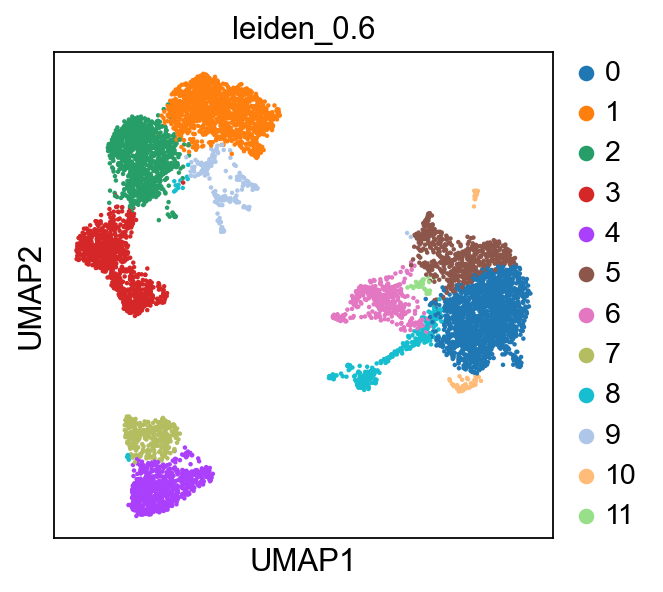

In [8]:
sc.pl.umap(adata, color='leiden_0.6')

## Differential Gene Expression (DGE) Analysis
Rank genes by statistical significance between clusters using different methods: t-test, t-test with overestimated variance, Wilcoxon, and logistic regression. This identifies genes that distinguish different cell clusters.

#### 1. Perform T test to see the differentially expressed genes between COVID-19 and control samples in the macrophage cluster

ranking genes
    finished (0:00:01)


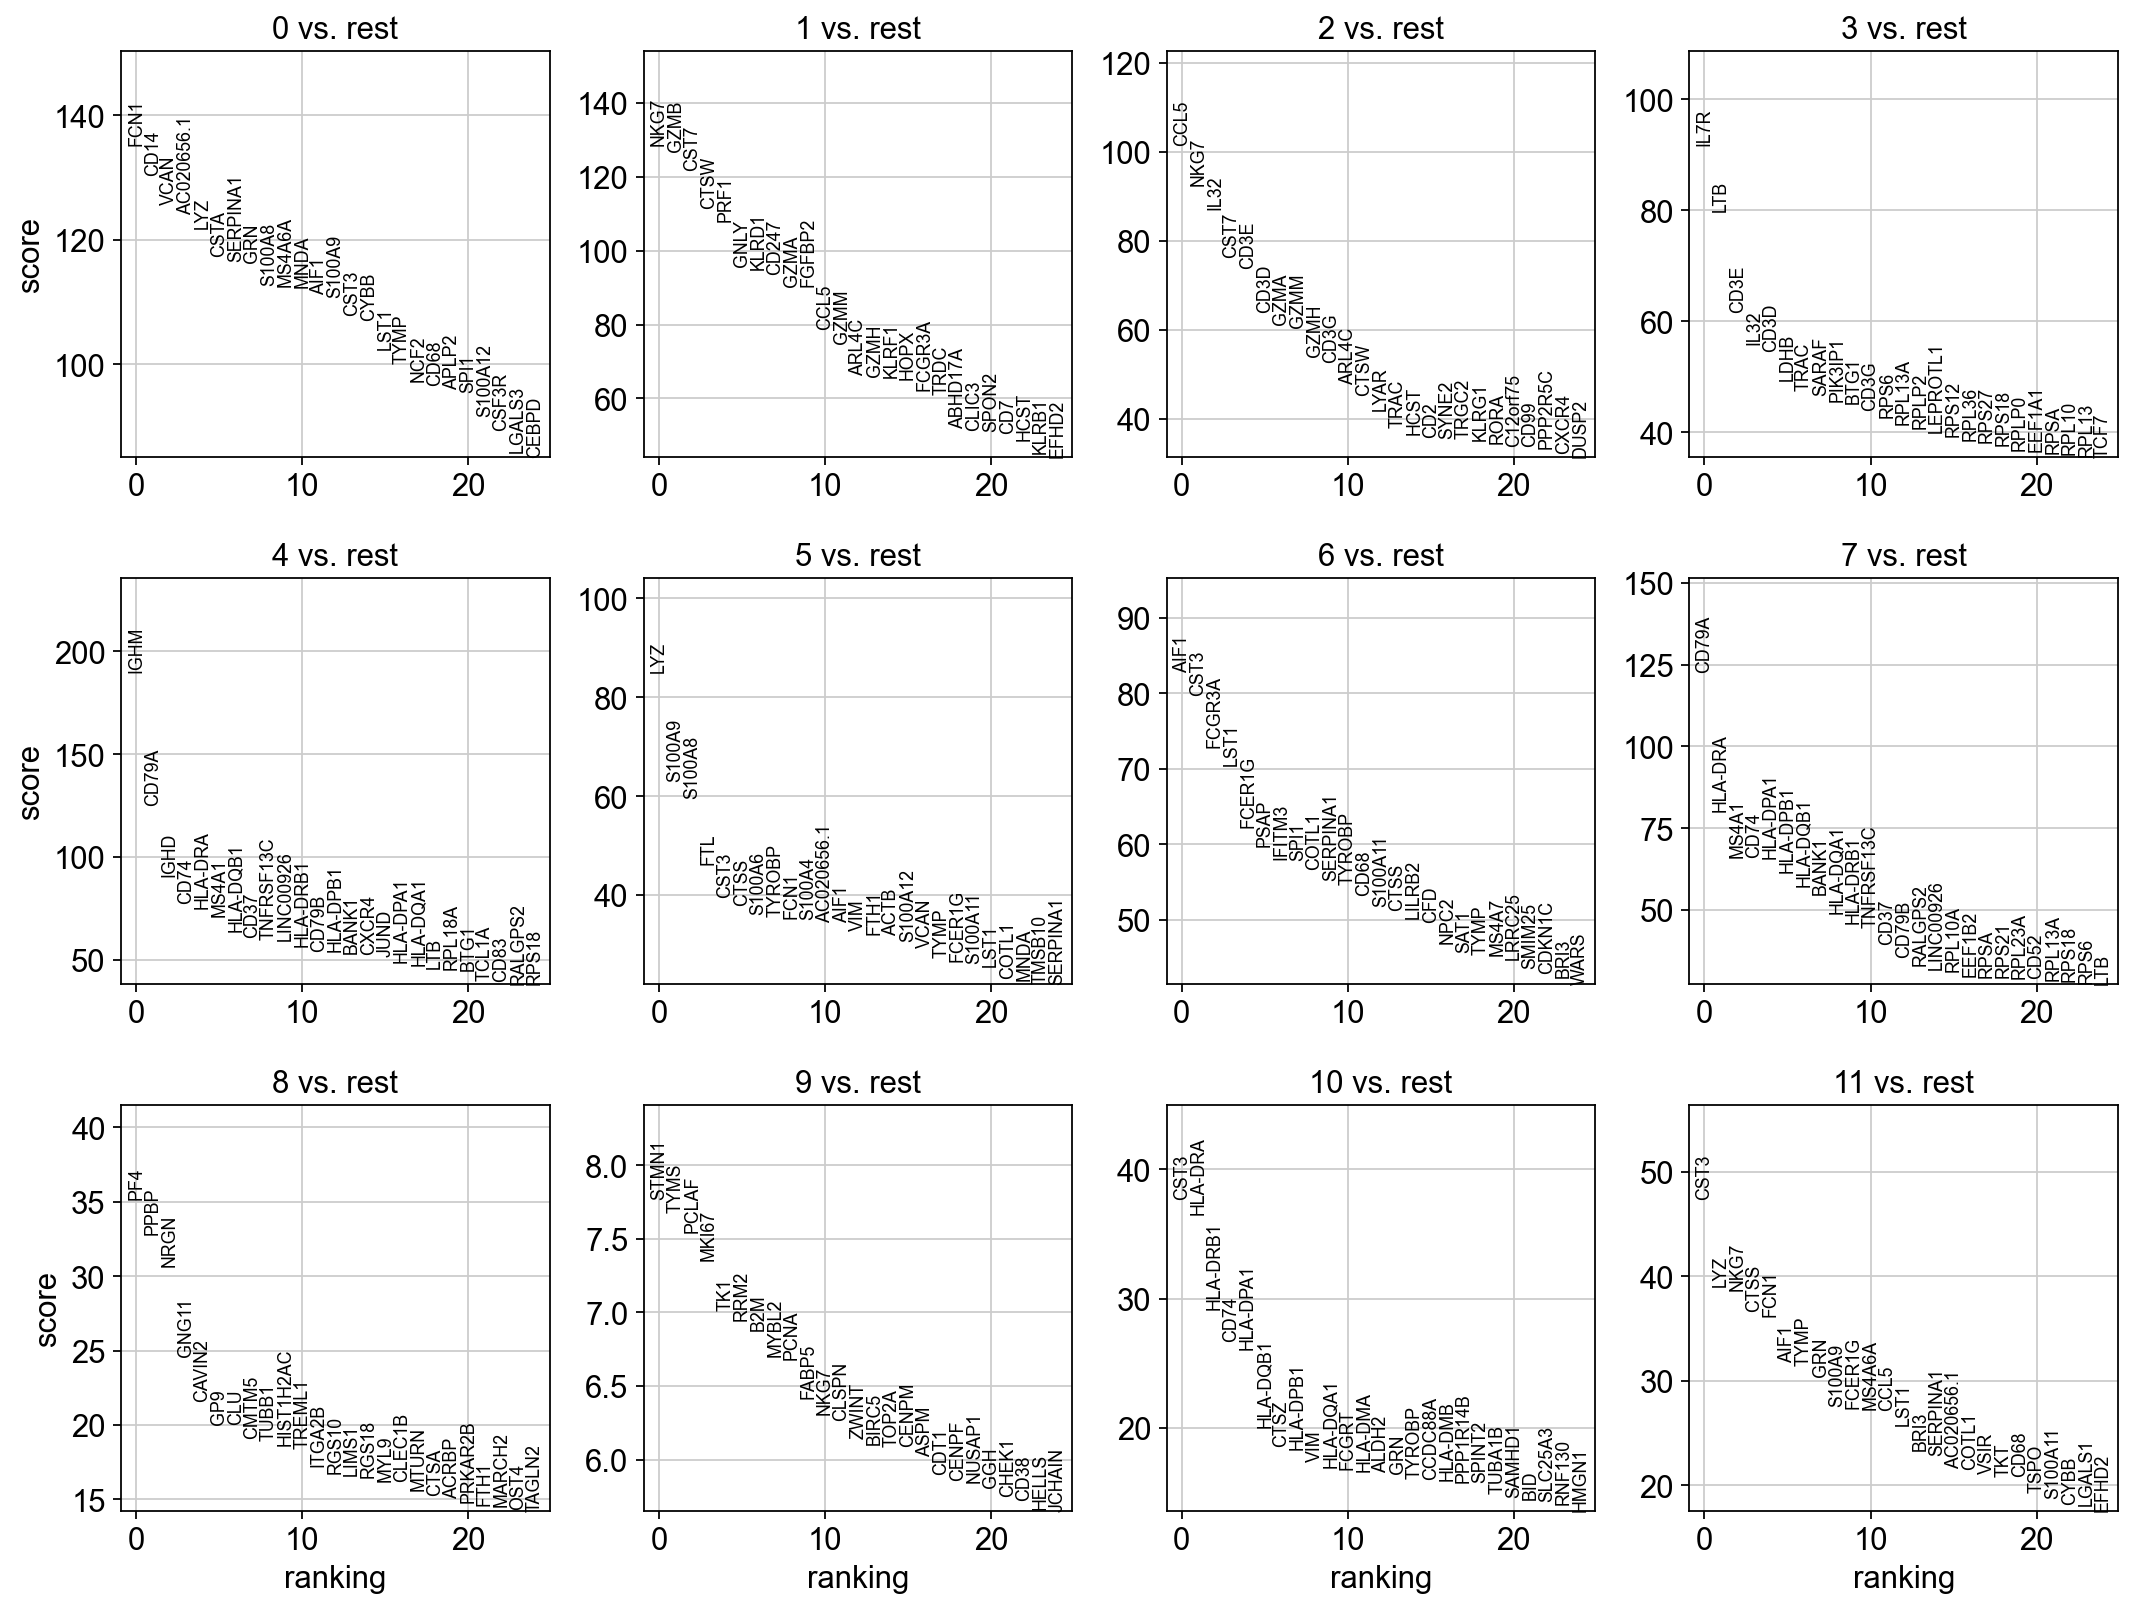

dict_keys(['dendrogram_leiden_0.6', 'doublet_info_colors', 'hclust_10_colors', 'hclust_15_colors', 'hclust_5_colors', 'hvg', 'kmeans10_colors', 'kmeans15_colors', 'kmeans5_colors', 'leiden', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_1.4', 'leiden_1.4_colors', 'log1p', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'tsne', 'umap', 't-test'])

In [9]:
sc.tl.rank_genes_groups(adata, 'leiden_0.6', method='t-test', key_added = "t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test")

# results are stored in the adata.uns["t-test"] slot
adata.uns.keys()

#### 2 T-test overestimated_variance

ranking genes
    finished (0:00:01)


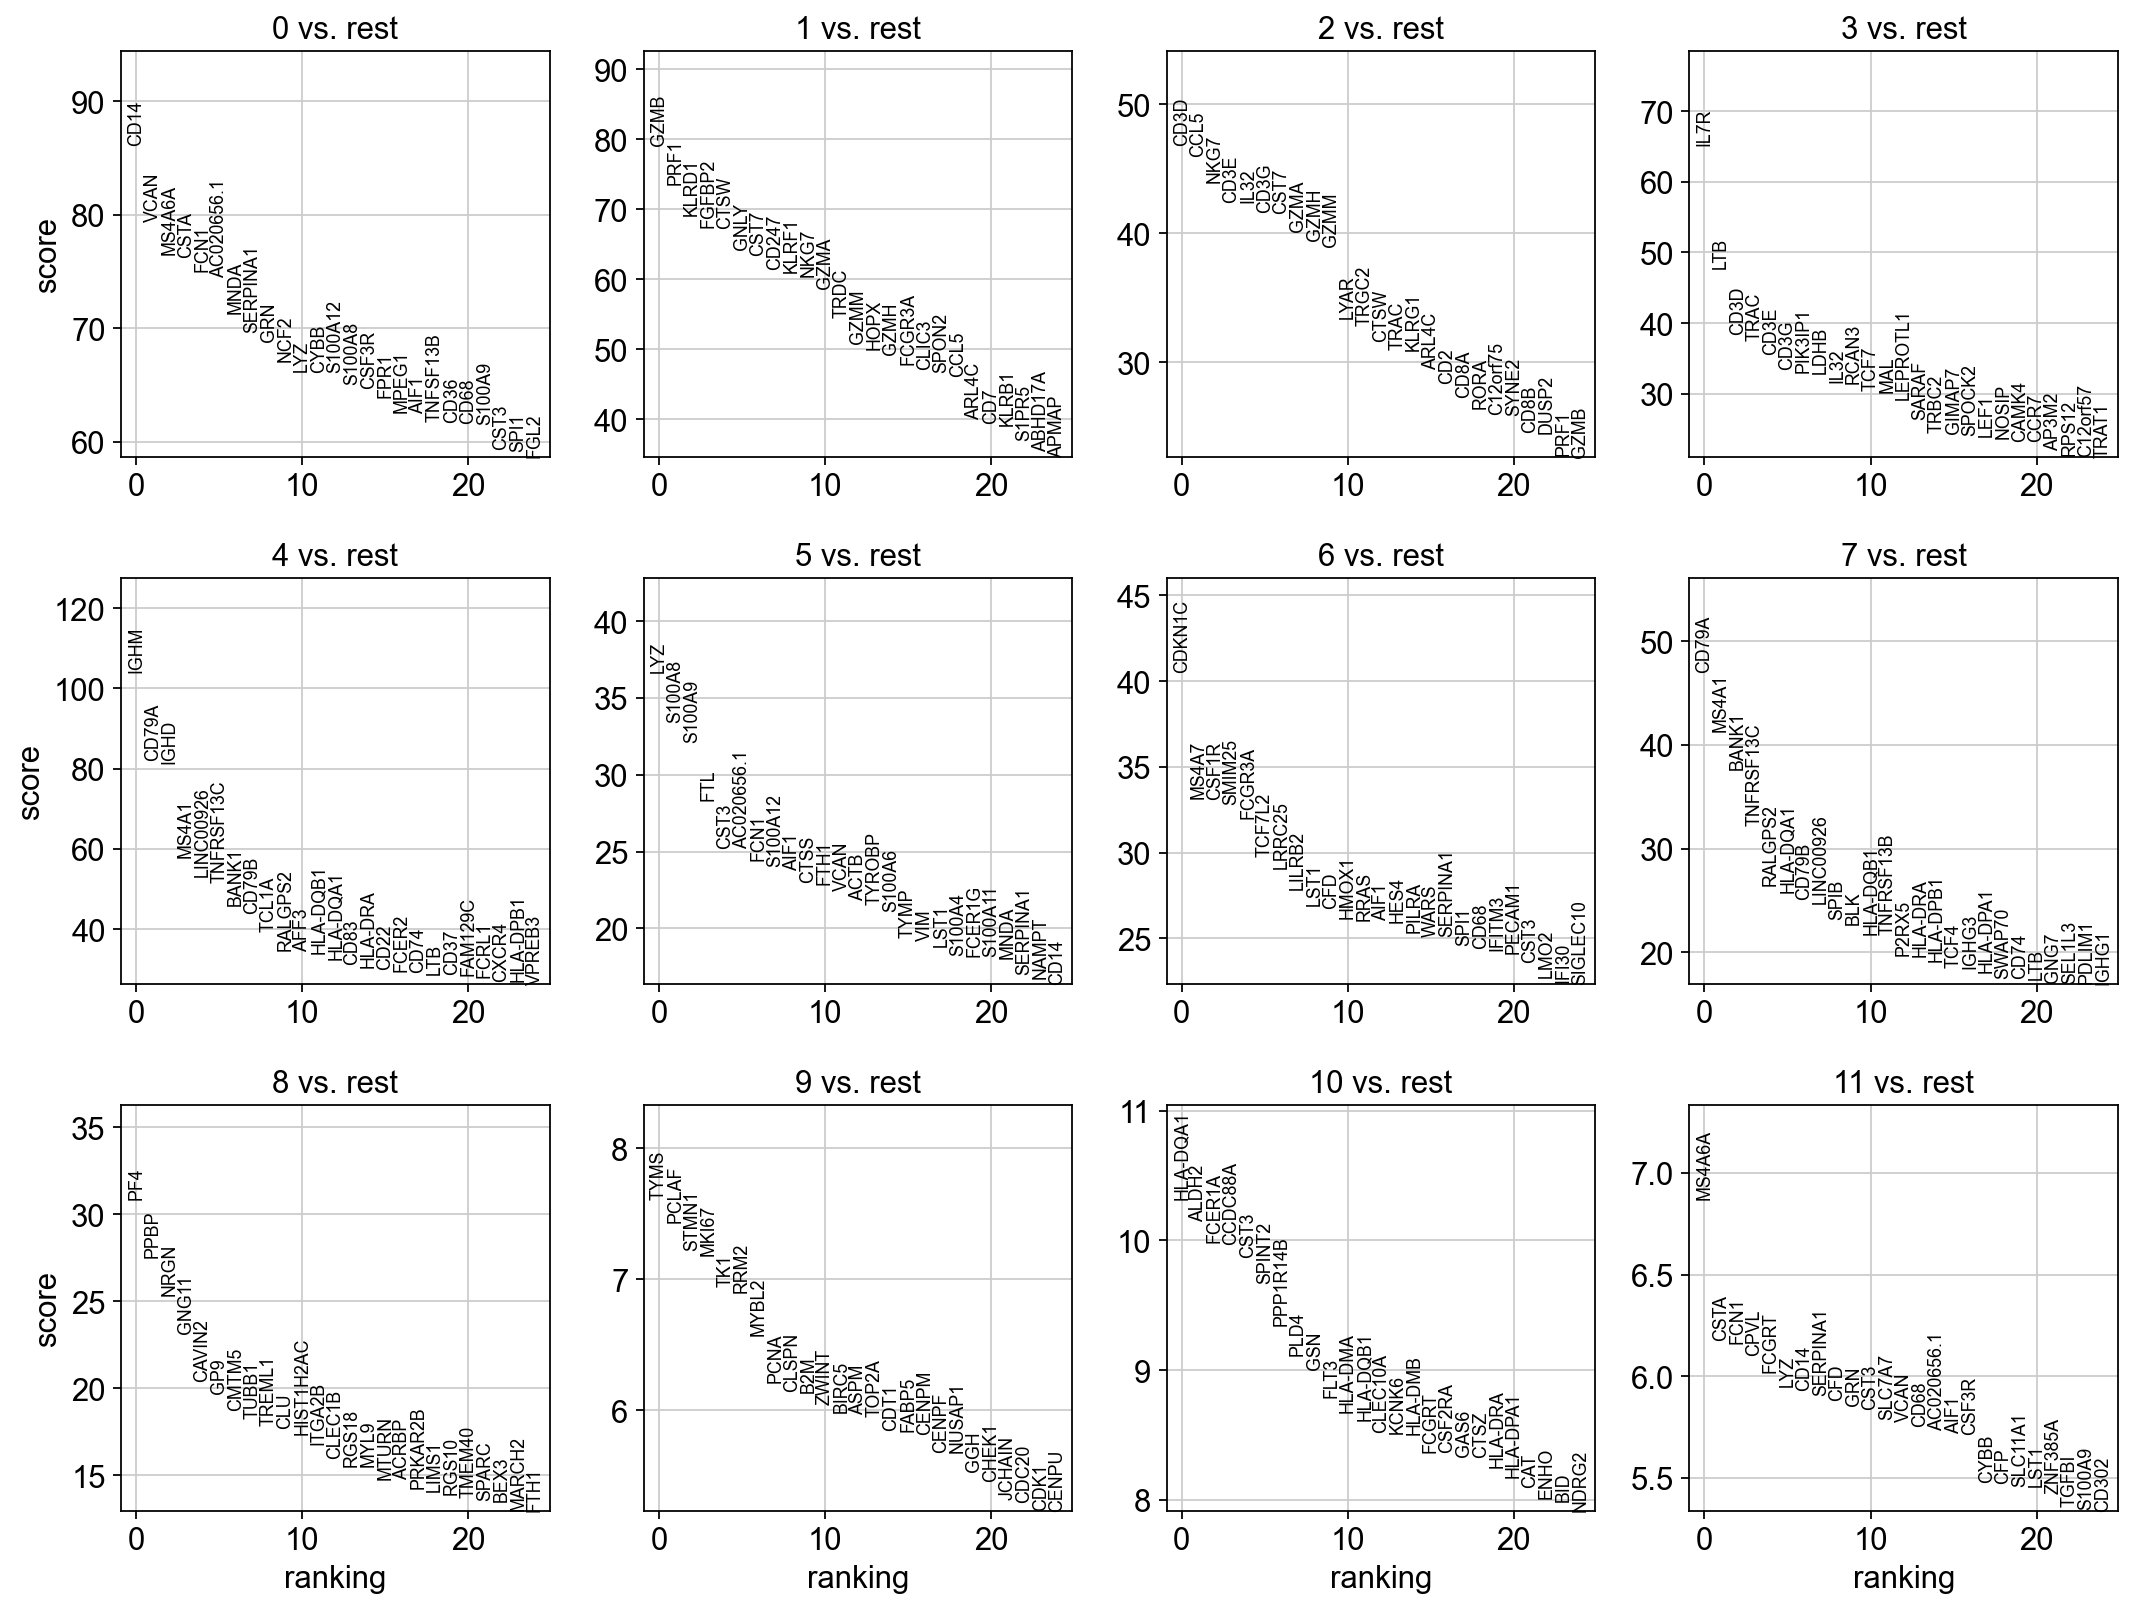

In [10]:
sc.tl.rank_genes_groups(adata, 'leiden_0.6', method='t-test_overestim_var', key_added = "t-test_ov")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test_ov")

#### 3. Wilcoxon

ranking genes
    finished (0:00:06)


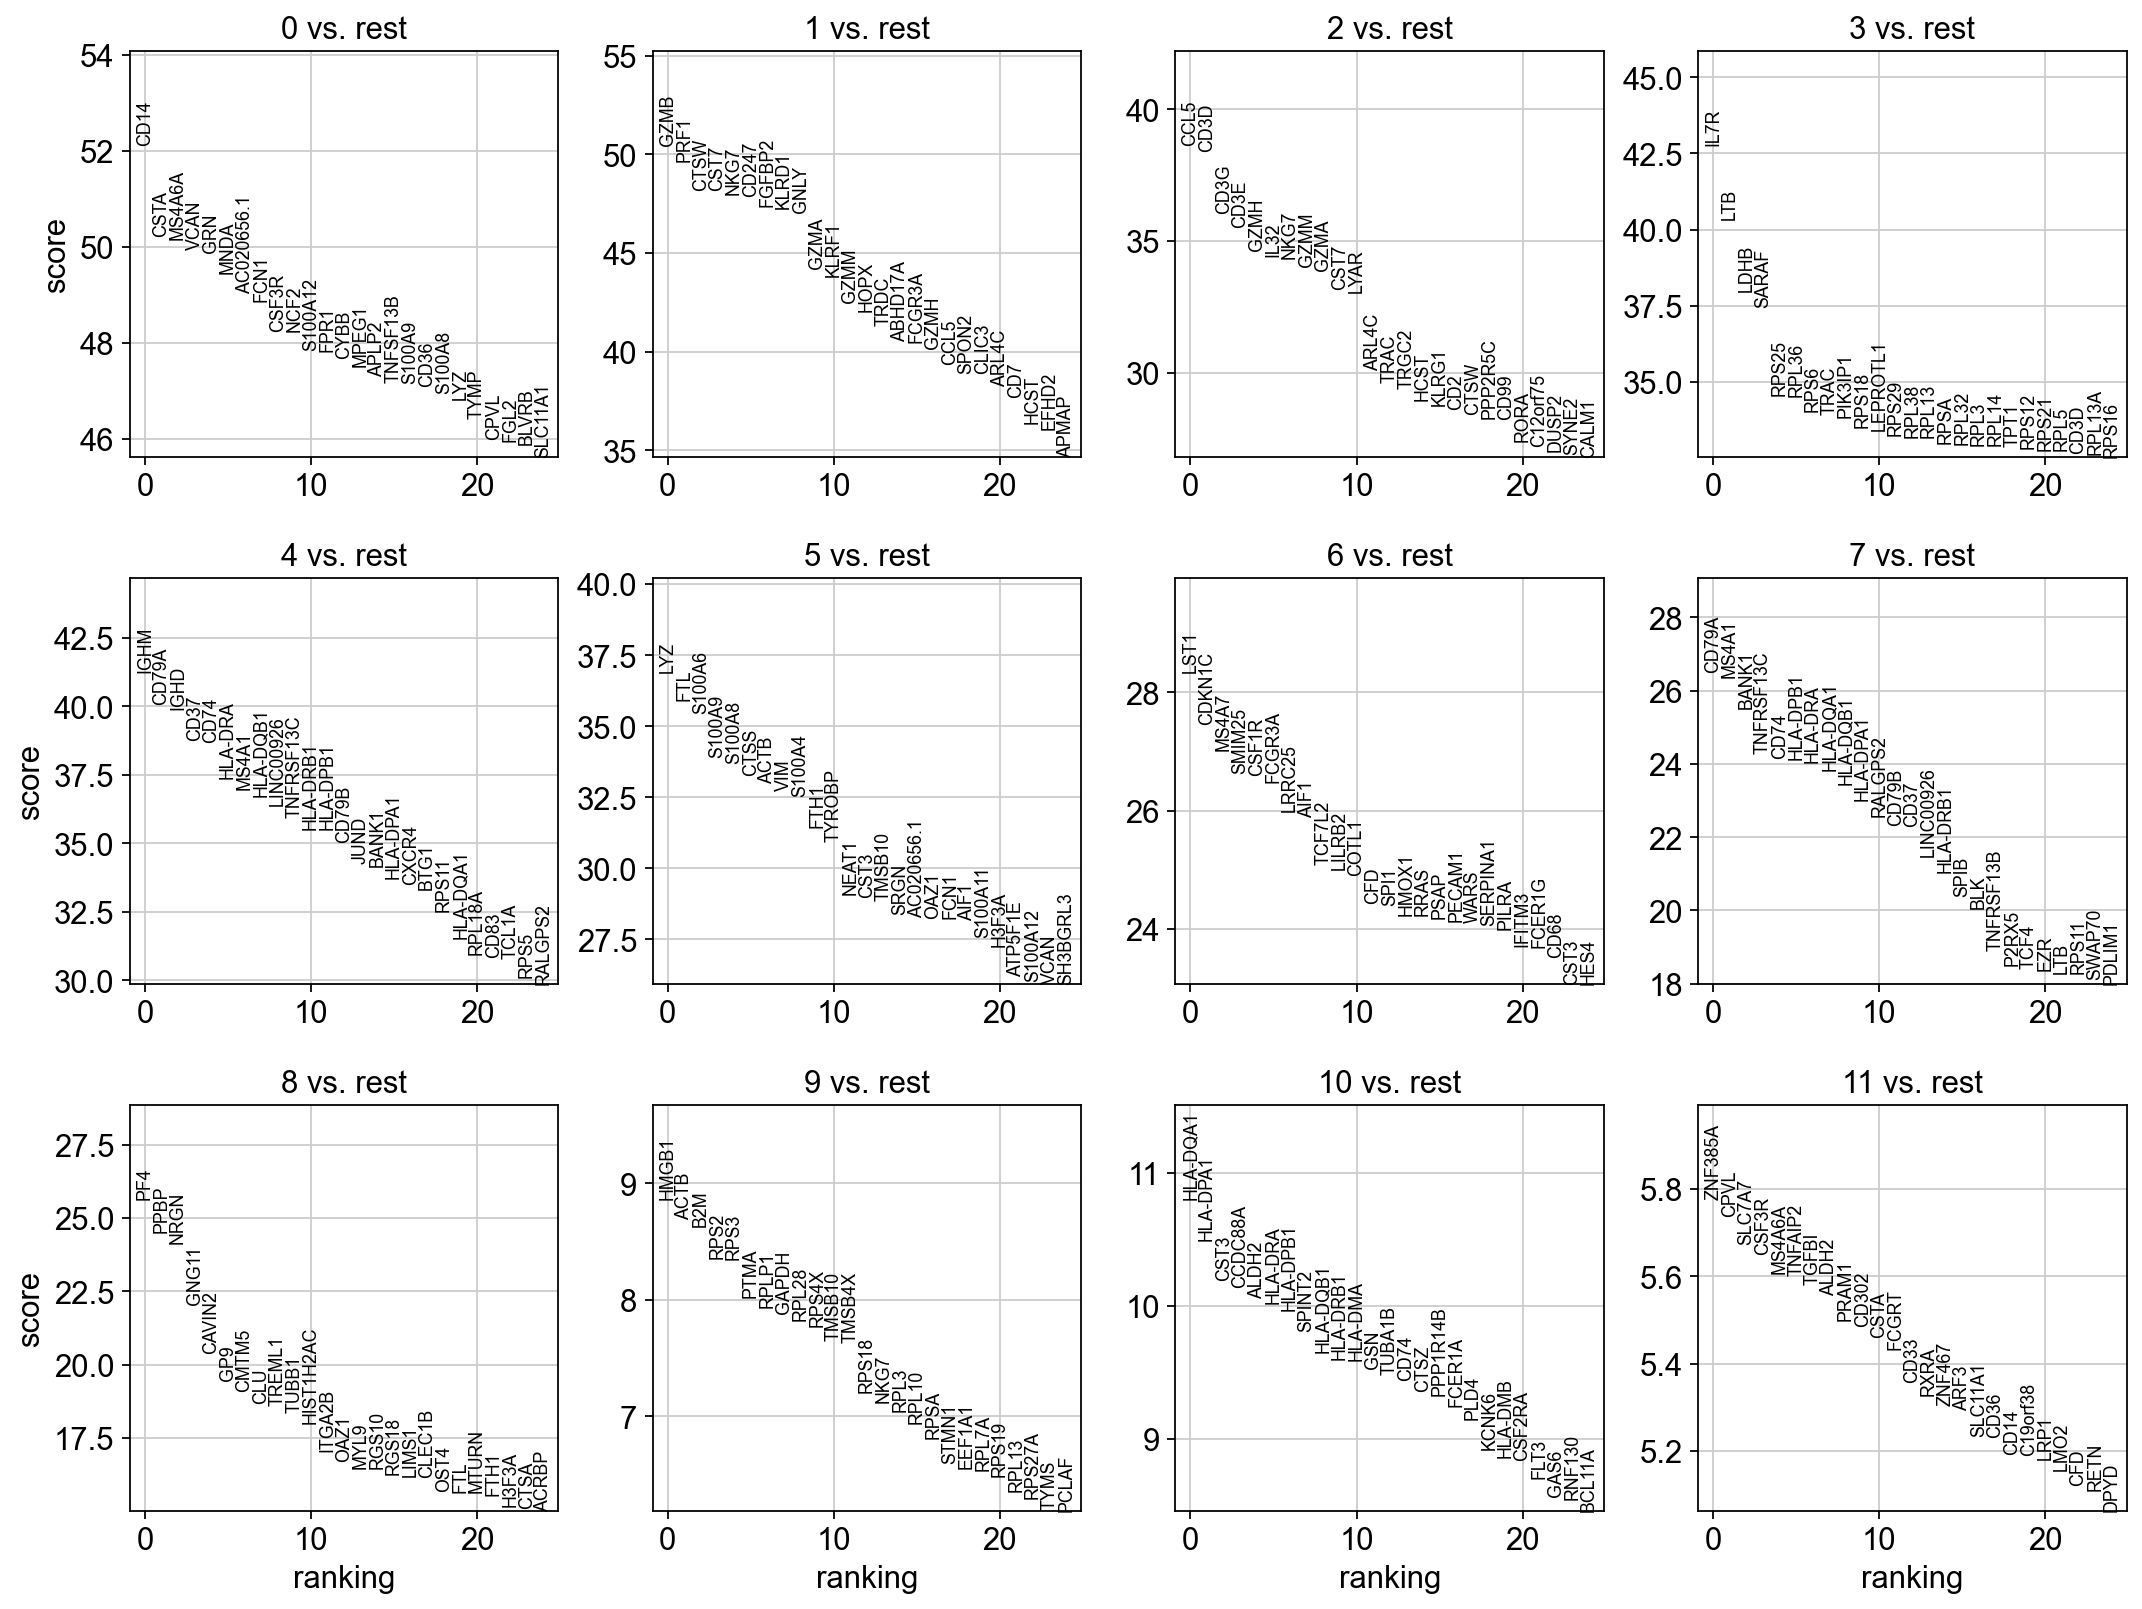

In [11]:
sc.tl.rank_genes_groups(adata, 'leiden_0.6', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key="wilcoxon")

#### 4 Logistic regression test

ranking genes
    finished (0:00:12)


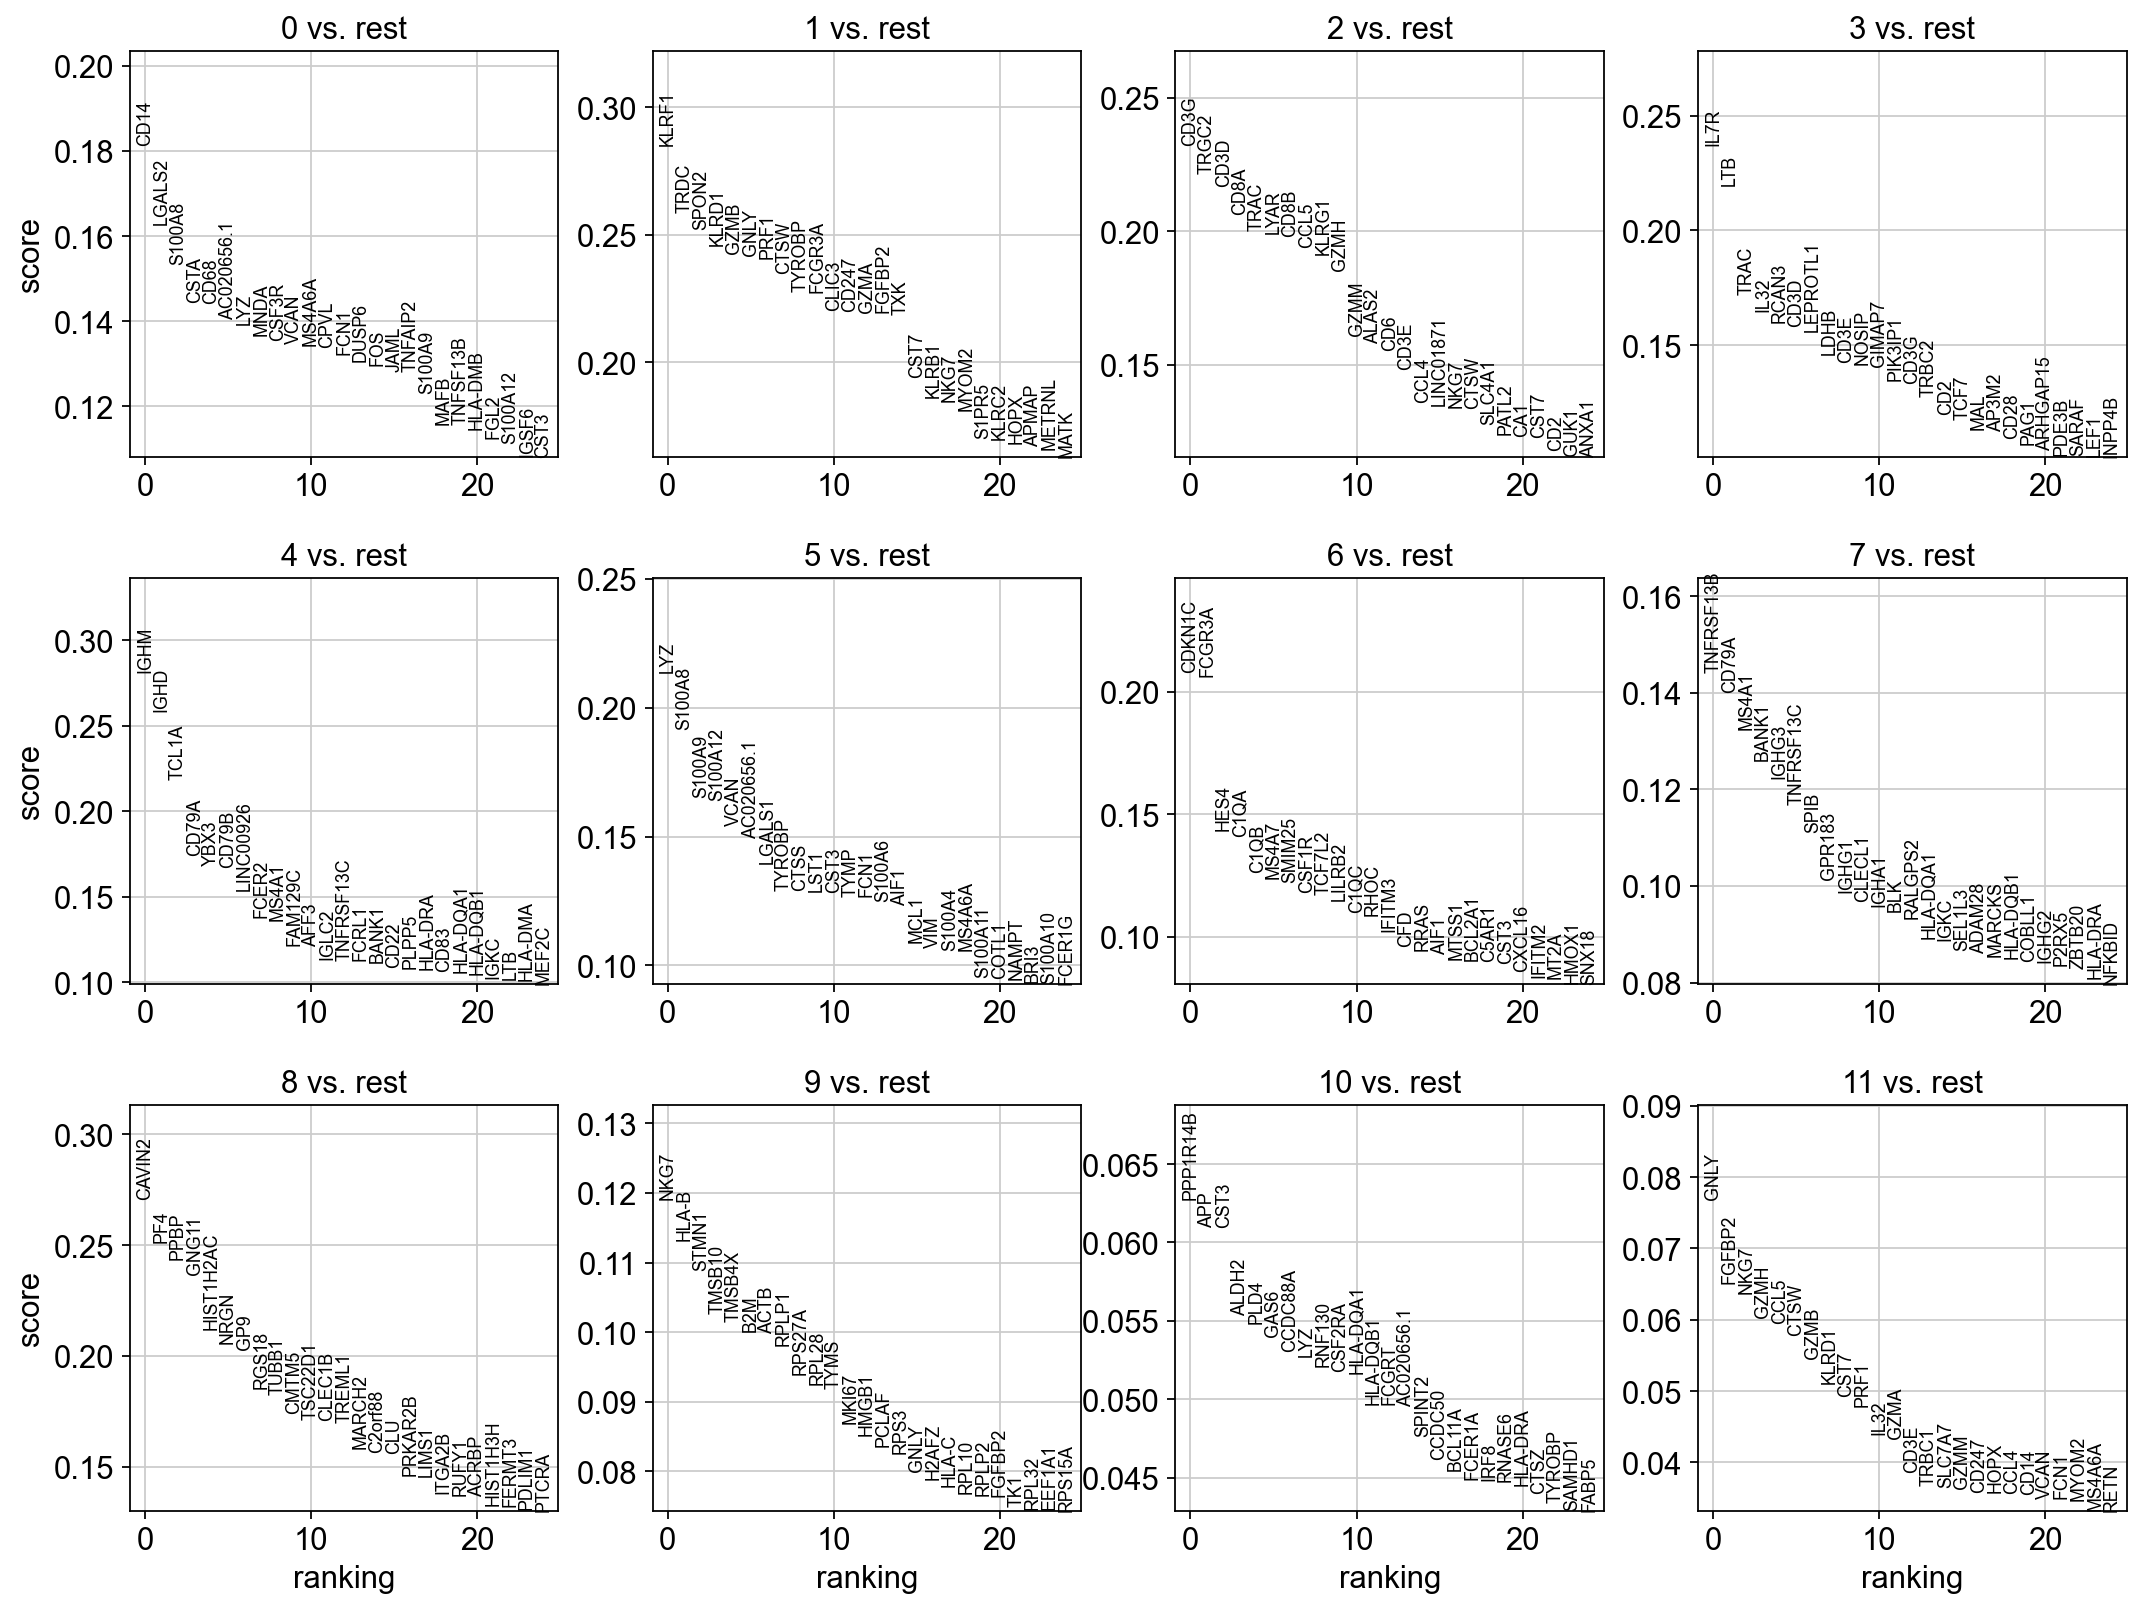

In [12]:
sc.tl.rank_genes_groups(adata, 'leiden_0.6', method='logreg',key_added = "logreg")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "logreg")

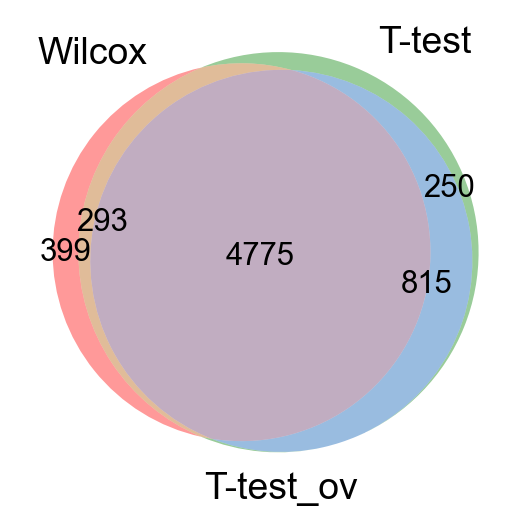

In [15]:
#compare cluster1 genes, only stores top 100 by default

wc = sc.get.rank_genes_groups_df(adata, group='0', key='wilcoxon', pval_cutoff=0.01, log2fc_min=0)['names']
tt = sc.get.rank_genes_groups_df(adata, group='0', key='t-test', pval_cutoff=0.01, log2fc_min=0)['names']
tt_ov = sc.get.rank_genes_groups_df(adata, group='0', key='t-test_ov', pval_cutoff=0.01, log2fc_min=0)['names']

from matplotlib_venn import venn3

venn3([set(wc),set(tt),set(tt_ov)], ('Wilcox','T-test','T-test_ov') )
plt.show()

## Visualization of DGE results
Visualize the top differentially expressed genes using violin plots, dot plots, and heatmaps to understand their expression patterns across clusters.

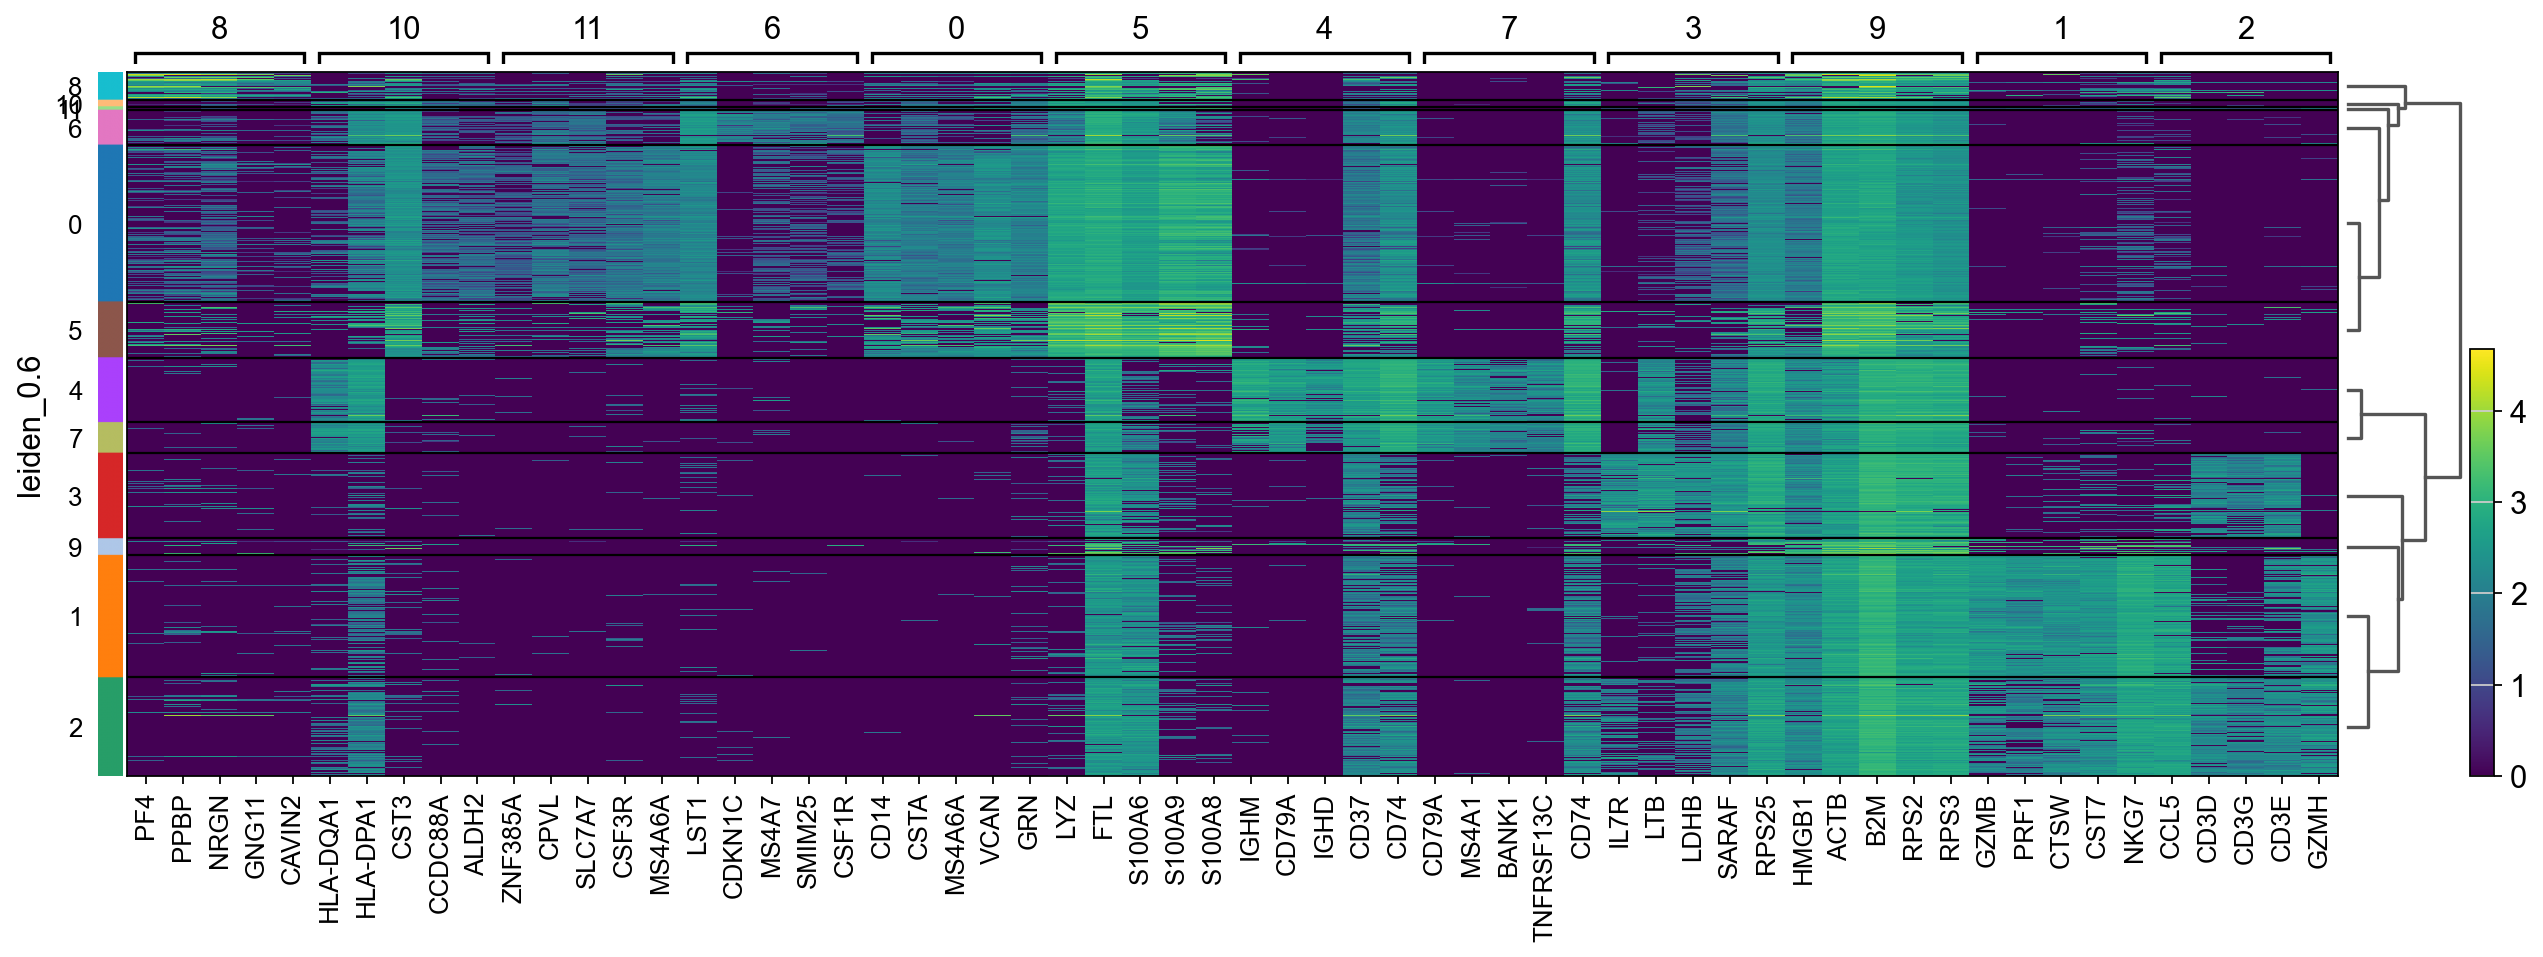

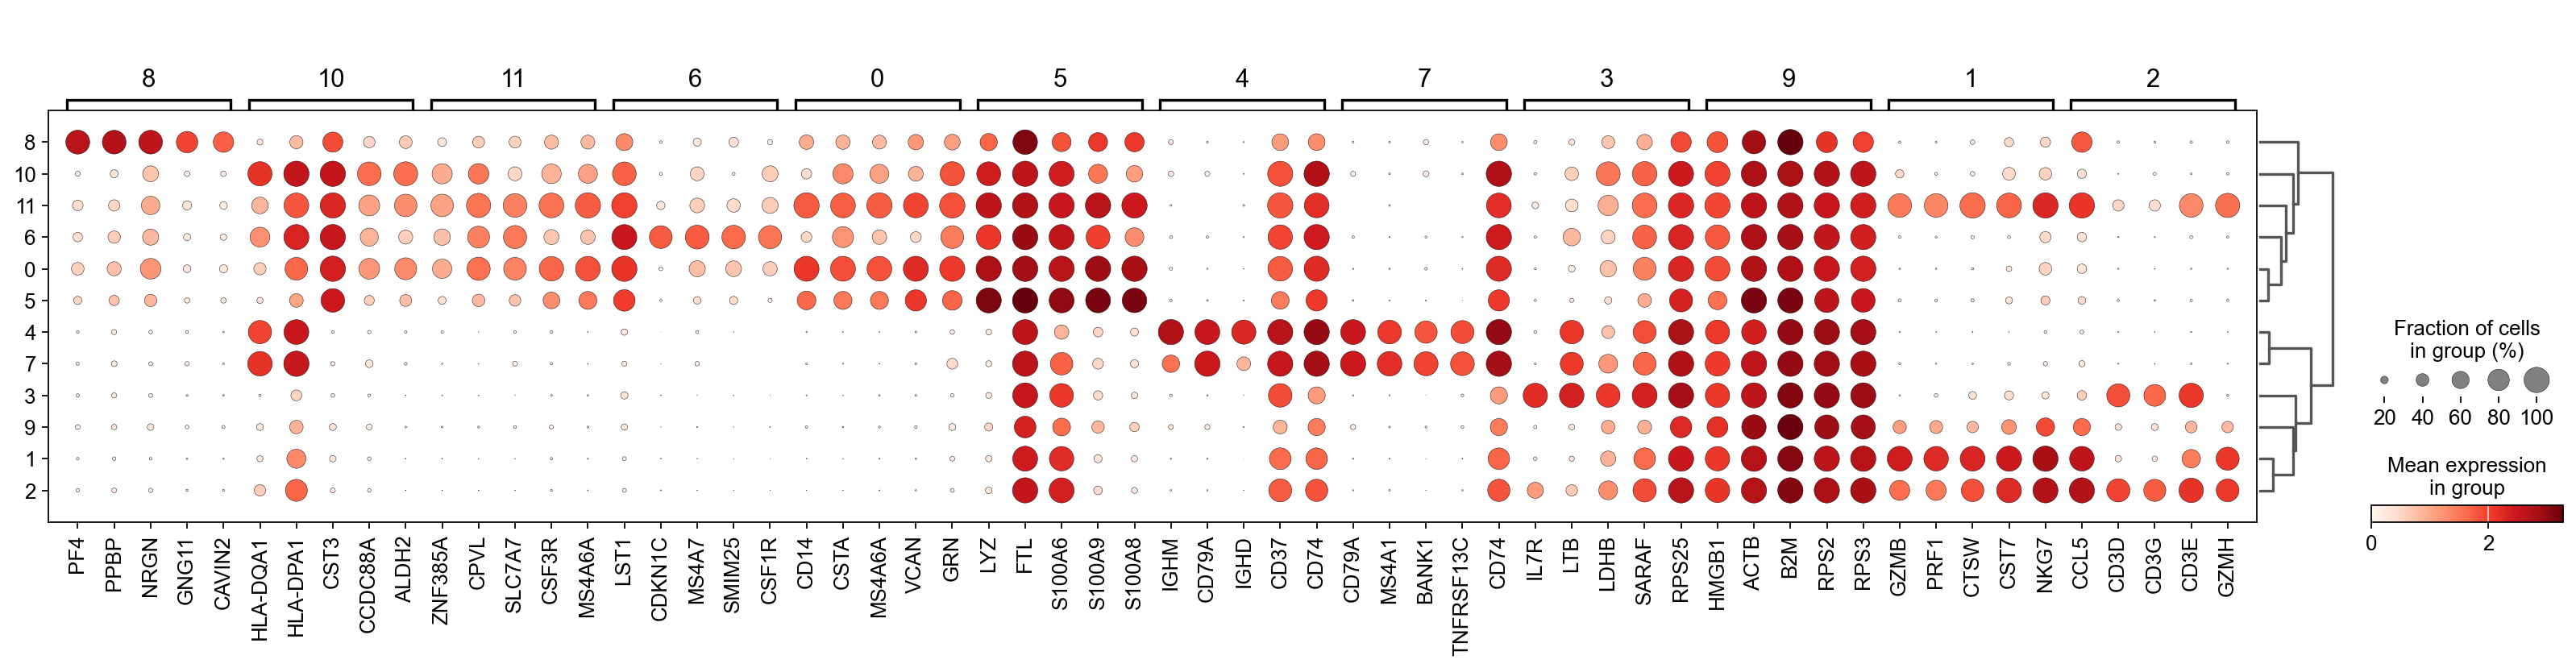

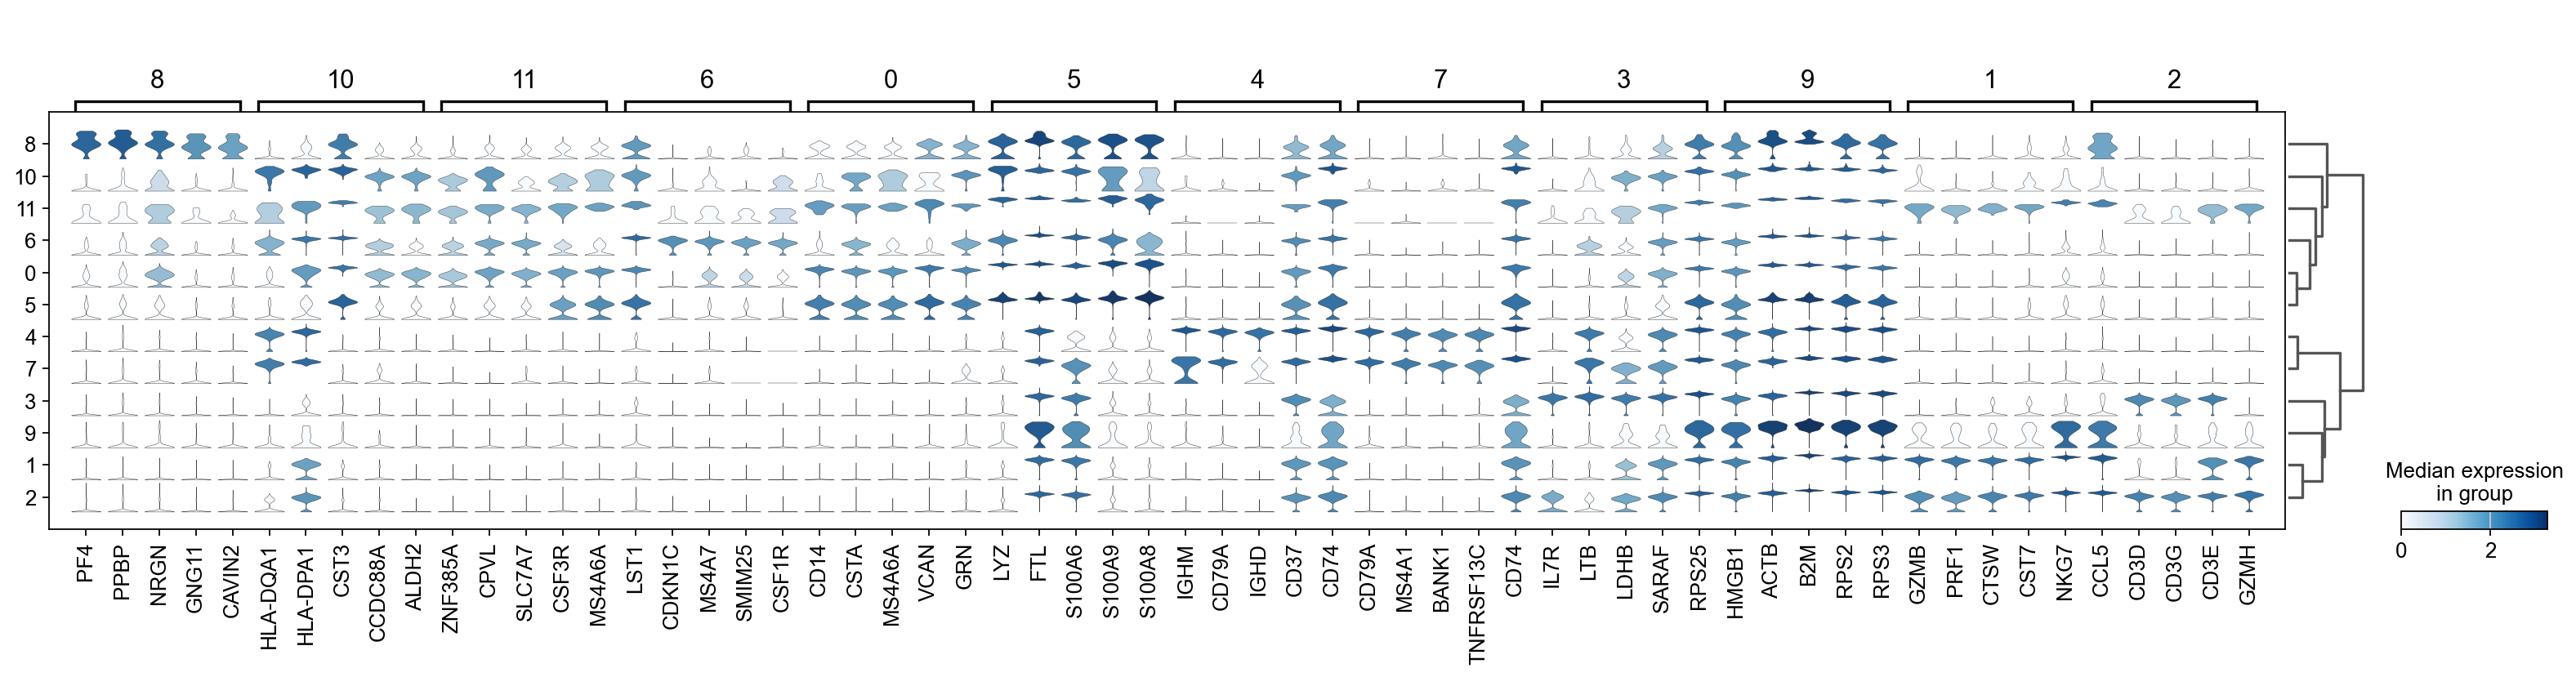

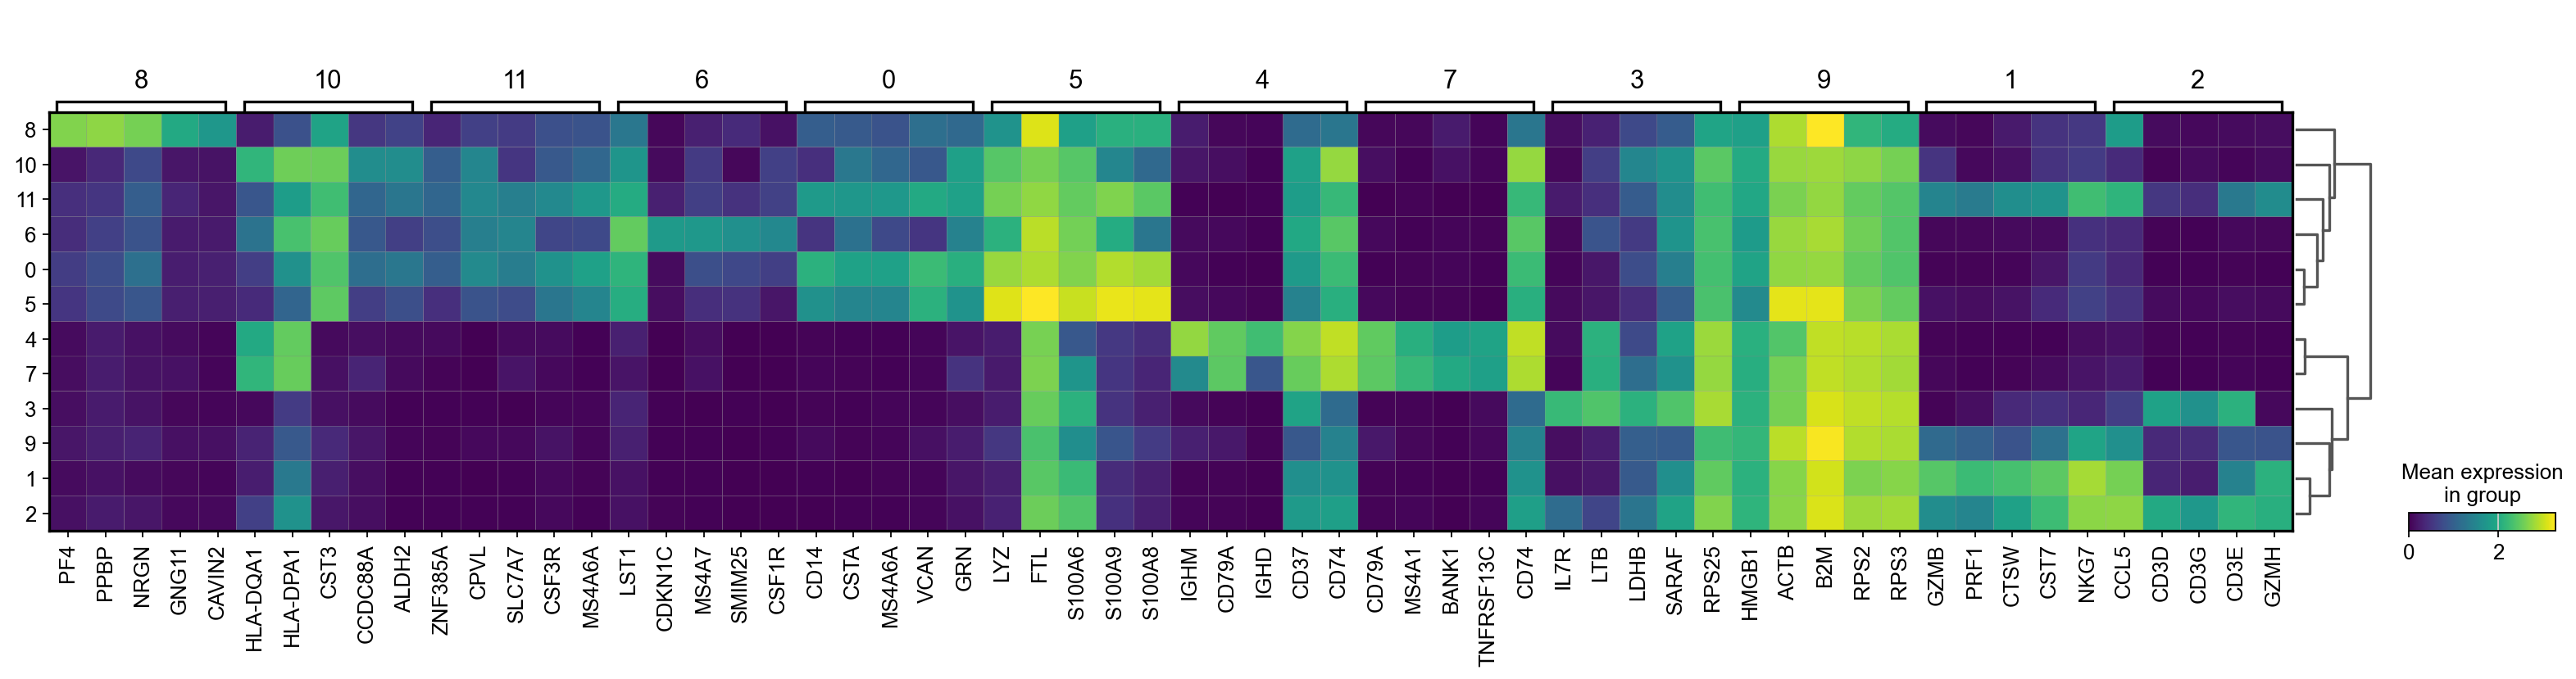

In [16]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, key="wilcoxon", groupby="leiden_0.6", show_gene_labels=True)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, key="wilcoxon", groupby="leiden_0.6")
sc.pl.rank_genes_groups_stacked_violin(adata, n_genes=5, key="wilcoxon", groupby="leiden_0.6")
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=5, key="wilcoxon", groupby="leiden_0.6")

## Visualize Top Marker Genes
Display top differentially expressed genes across clusters using multiple visualization types: heatmap (expression levels), dotplot (size/color indicate expression), violin plots (distribution), and matrix plots (comprehensive view of expression patterns).

ranking genes
    finished (0:00:00)


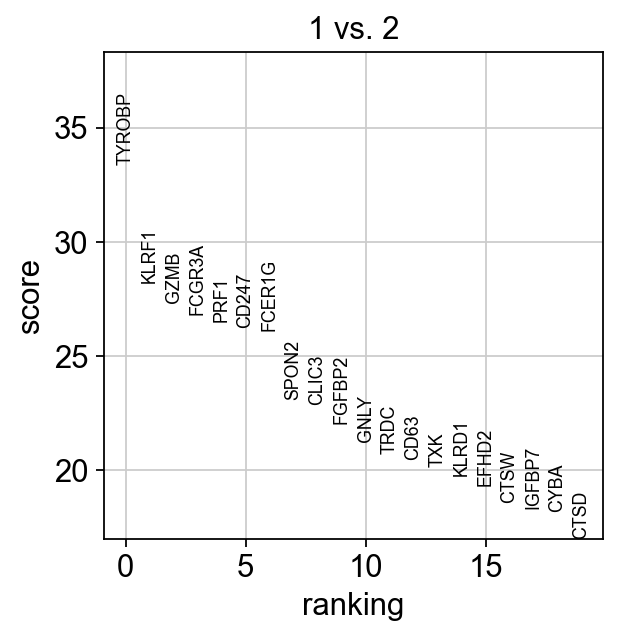

In [17]:
sc.tl.rank_genes_groups(adata, 'leiden_0.6', groups=['1'], reference='2', method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=['1'], n_genes=20)

#### Plot genes based on ranks

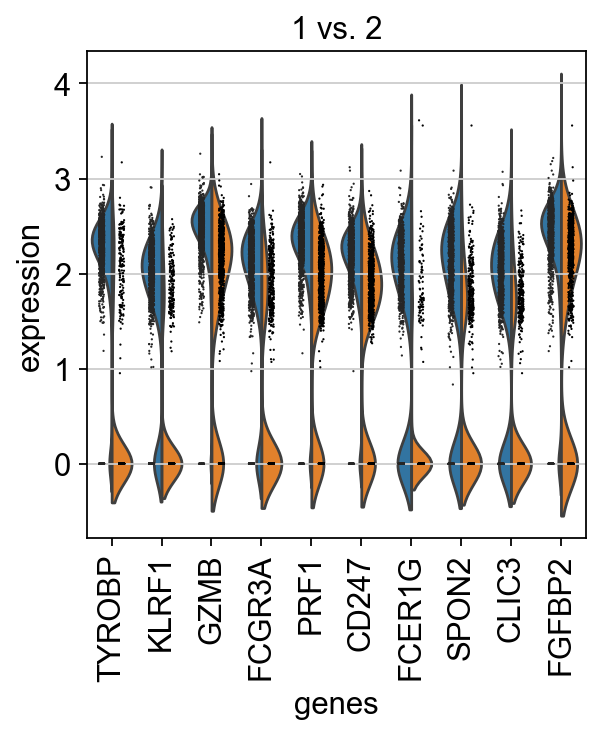

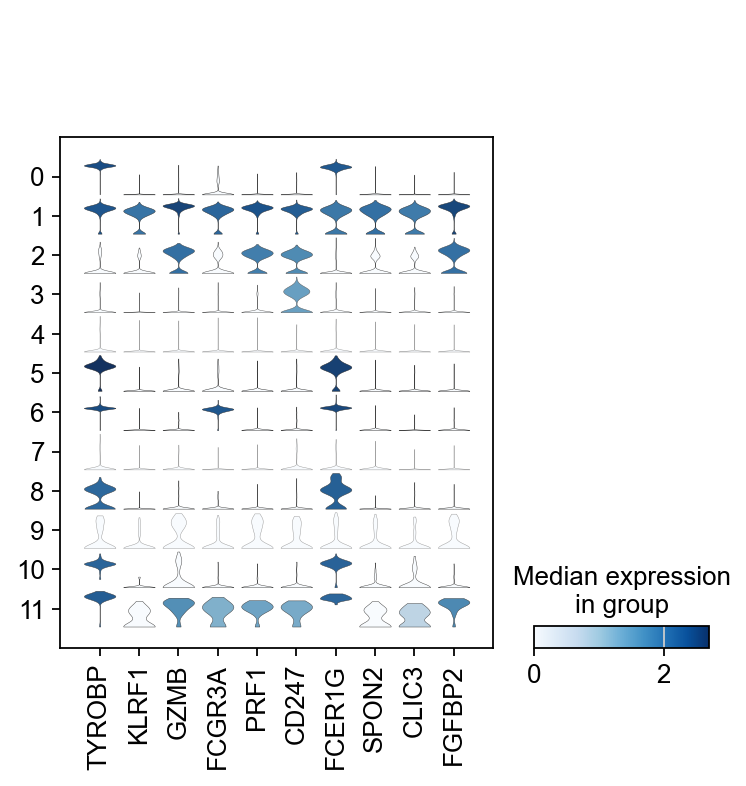

In [18]:
sc.pl.rank_genes_groups_violin(adata, groups='1', n_genes=10)

# plot the same genes as violins across all the datasets.

# convert numpy.recarray to list
mynames = [x[0] for x in adata.uns['rank_genes_groups']['names'][:10]]
sc.pl.stacked_violin(adata, mynames, groupby = 'leiden_0.6')

### perform DGE across conditions

ranking genes
    finished (0:00:00)


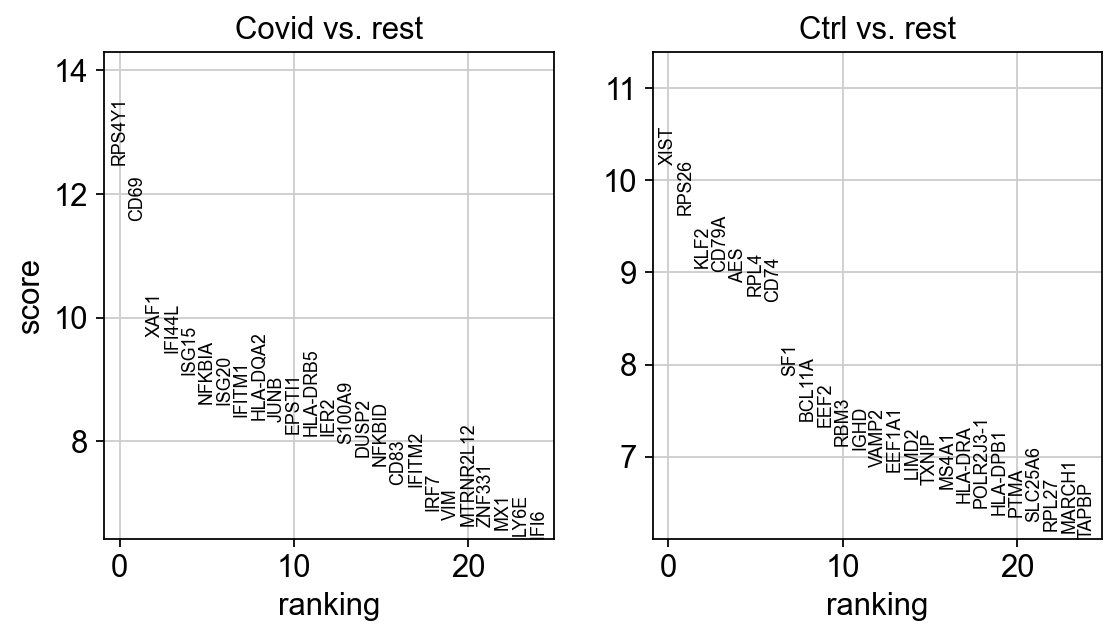

In [19]:
cl1 = adata[adata.obs['leiden_0.6'] == '4',:]
cl1.obs['type'].value_counts()

sc.tl.rank_genes_groups(cl1, 'type', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(cl1, n_genes=25, sharey=False, key="wilcoxon")

## Focus on Cluster 4 - COVID vs Control Comparison
Subset to cluster 4 and compare gene expression between COVID-19 and control samples. This identifies genes responding to COVID infection in this specific cell type.

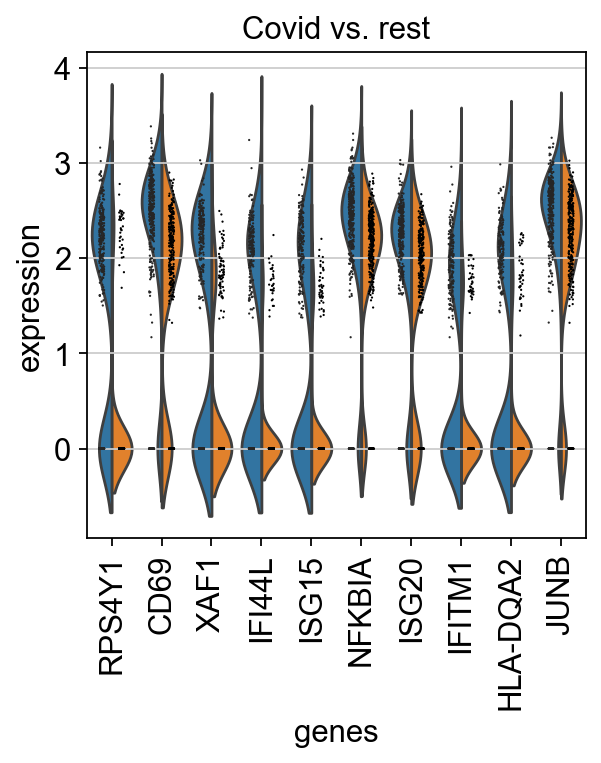

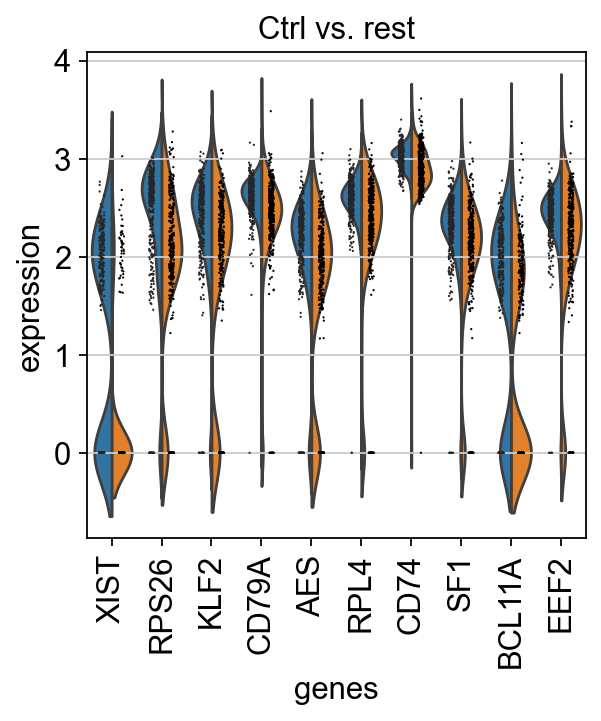

In [20]:
sc.pl.rank_genes_groups_violin(cl1, n_genes=10, key="wilcoxon")

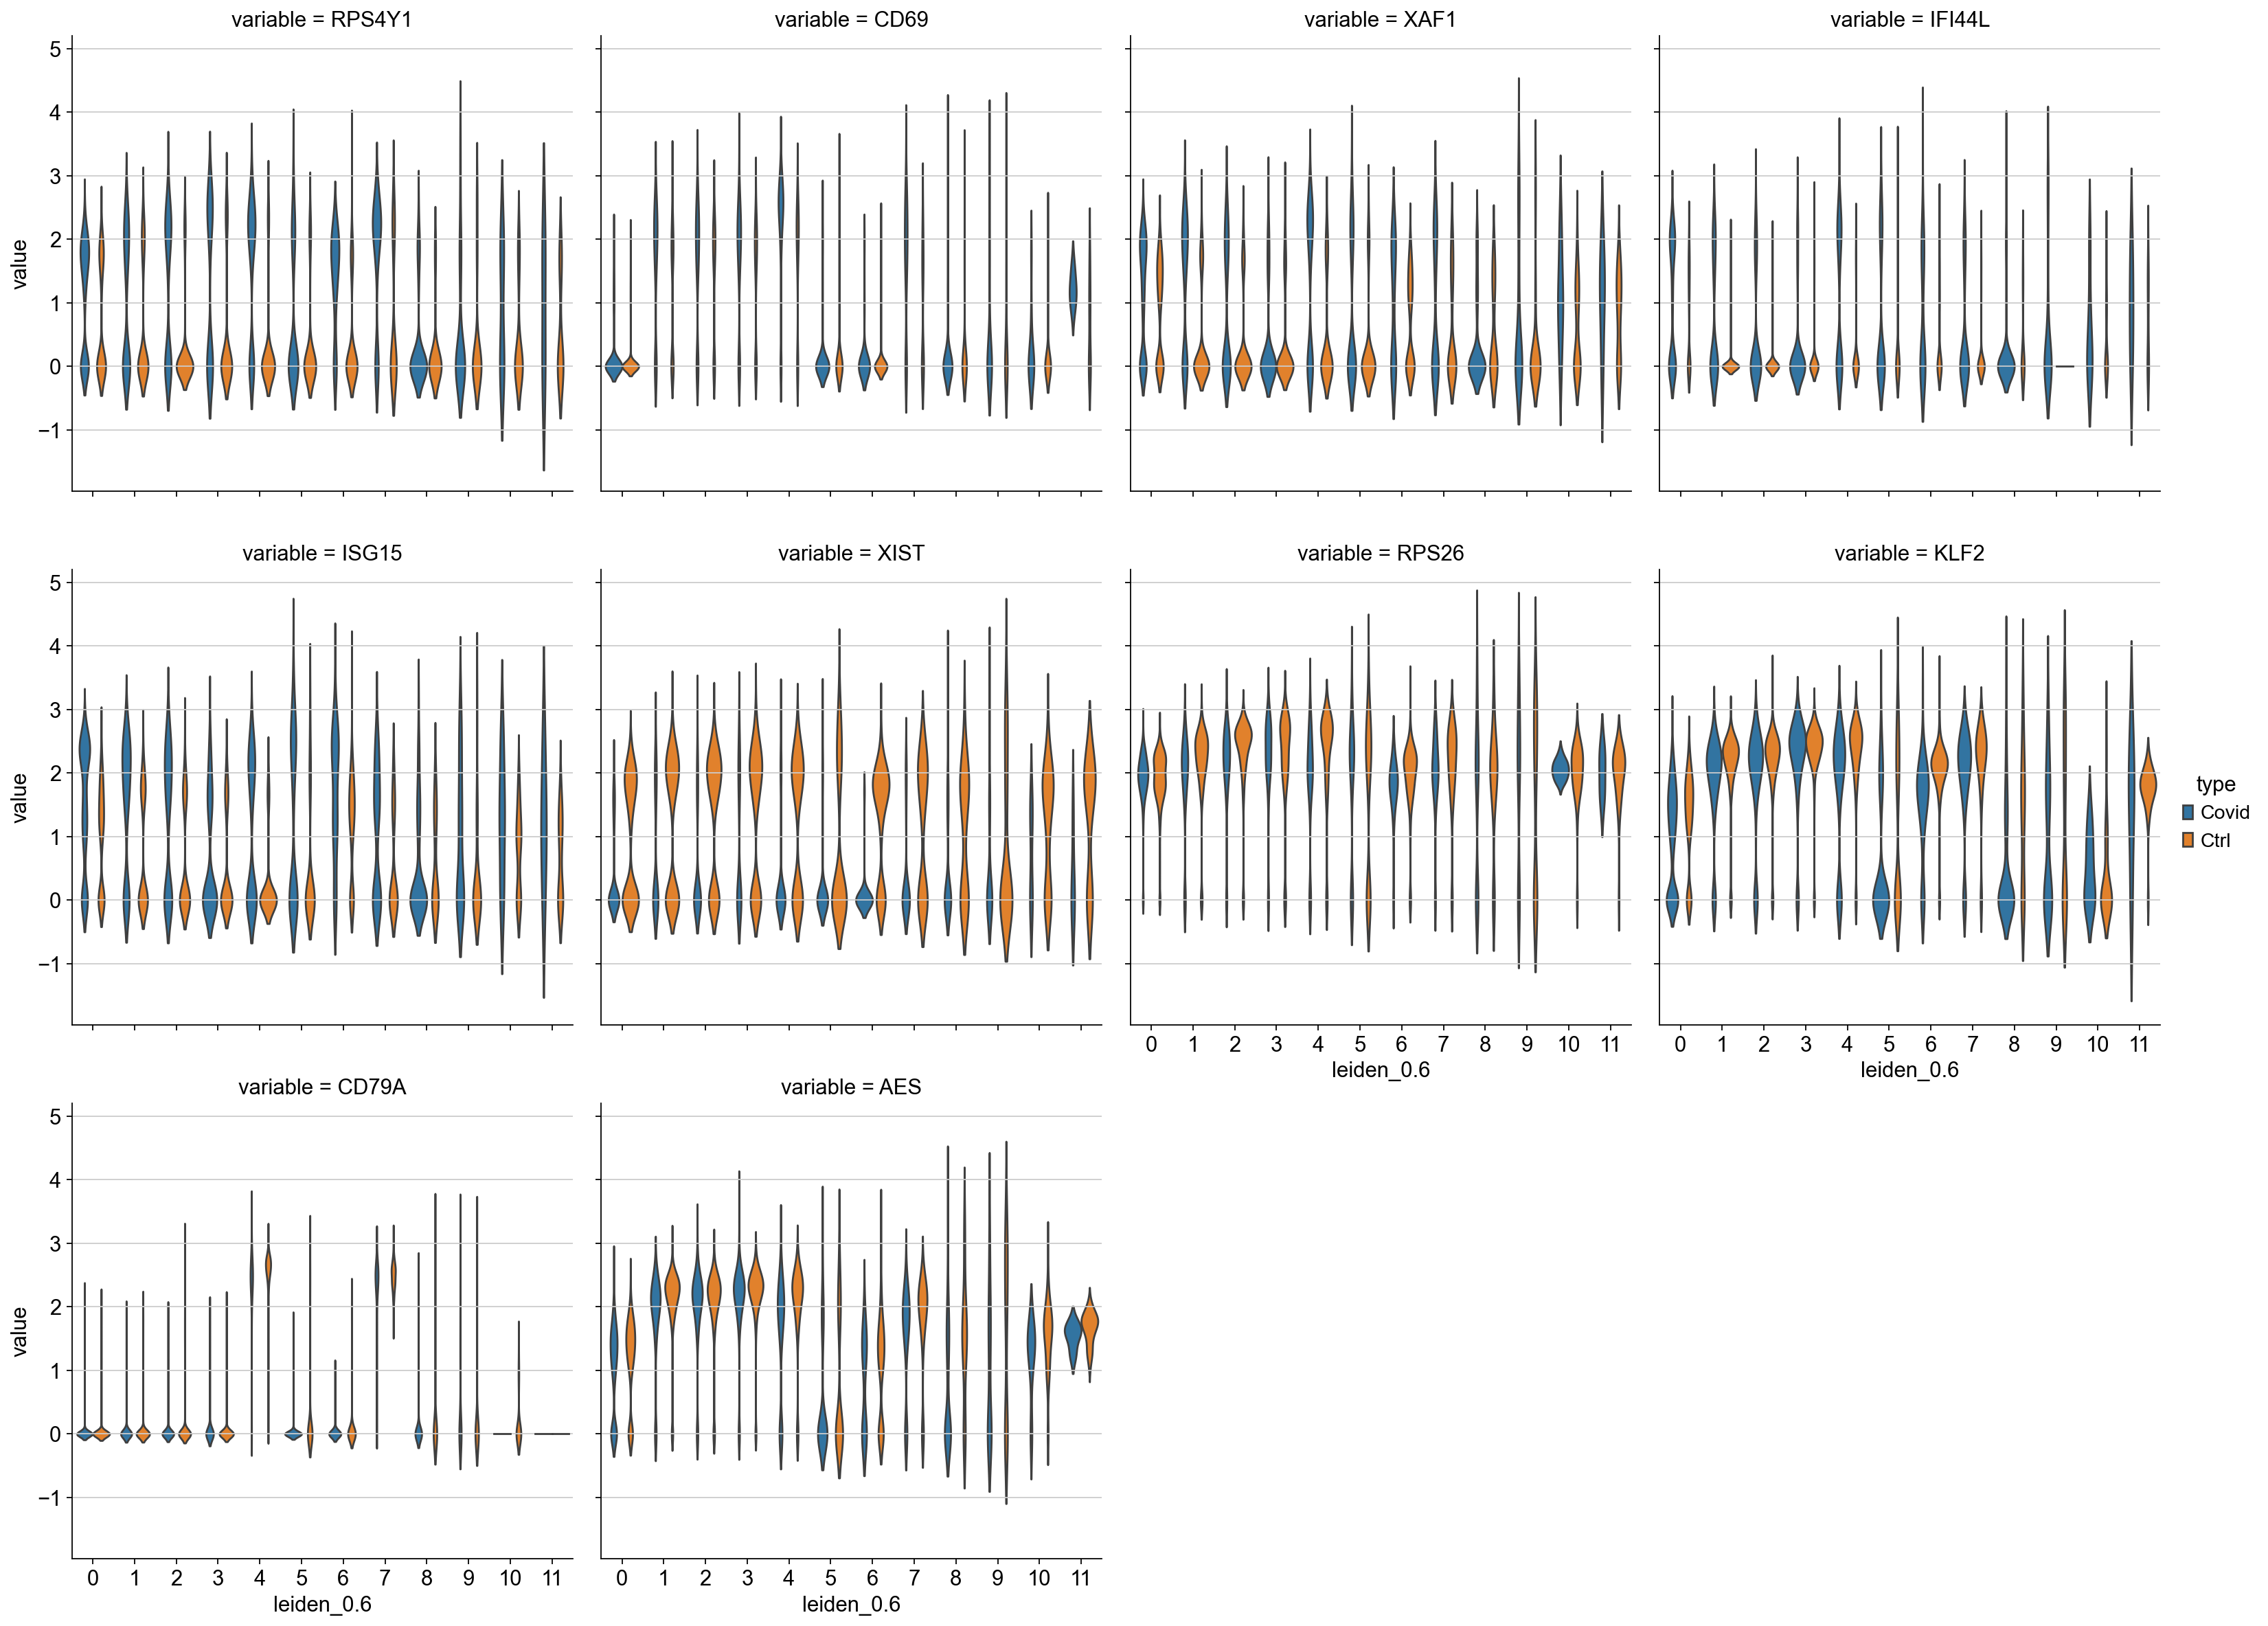

In [21]:
import seaborn as sns

genes1 = sc.get.rank_genes_groups_df(cl1, group='Covid', key='wilcoxon')['names'][:5]
genes2 = sc.get.rank_genes_groups_df(cl1, group='Ctrl', key='wilcoxon')['names'][:5]
genes = genes1.tolist() +  genes2.tolist() 
df = sc.get.obs_df(adata, genes + ['leiden_0.6','type'], use_raw=True)
df2 = df.melt(id_vars=["leiden_0.6",'type'], value_vars=genes)

sns.catplot(x = "leiden_0.6", y = "value", hue = "type", kind = 'violin', col = "variable", data = df2, col_wrap=4, inner=None)

## Remove Sex Chromosome Genes
Filter out genes from sex chromosomes (X and Y) to reduce confounding effects from sex-specific gene expression. Uses a fallback list of common sex chromosome genes when external annotation sources are unavailable.

In [ ]:
annot_file = '/Users/varunshamanna/Downloads/snapy_tutorials/de_tut/gene_annotations_pybiomart.csv'

if not os.path.exists(annot_file):
    annot = sc.queries.biomart_annotations("hsapiens", ["ensembl_gene_id", "external_gene_name", "start_position", "end_position", "chromosome_name"], use_cache=False).set_index("external_gene_name")
    annot.to_csv(annot_file)
else:
    annot = pd.read_csv(annot_file, index_col=0)

chrY_genes = adata.var_names.intersection(annot.index[annot.chromosome_name == "Y"])
chrX_genes = adata.var_names.intersection(annot.index[annot.chromosome_name == "X"])

sex_genes = chrY_genes.union(chrX_genes)
print(len(sex_genes))
all_genes = cl1.var.index.tolist()
print(len(all_genes))

keep_genes = [x for x in all_genes if x not in sex_genes]
print(len(keep_genes))

cl1 = cl1[:,keep_genes]

ranking genes
    finished (0:00:00)


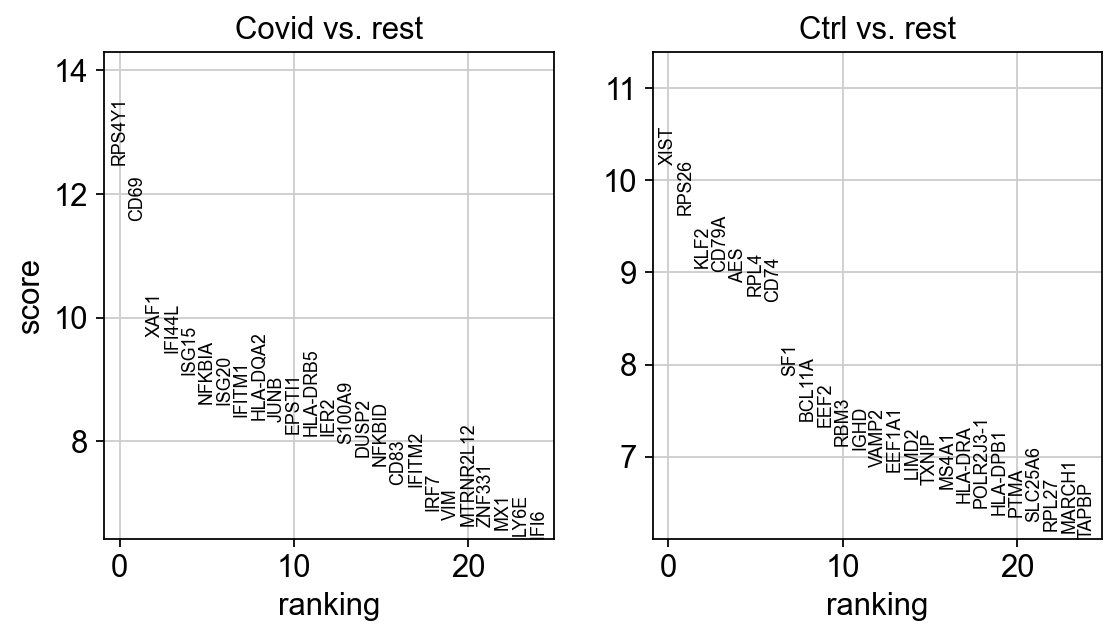

In [31]:
sc.tl.rank_genes_groups(cl1, 'type', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(cl1, n_genes=25, sharey=False, key="wilcoxon")

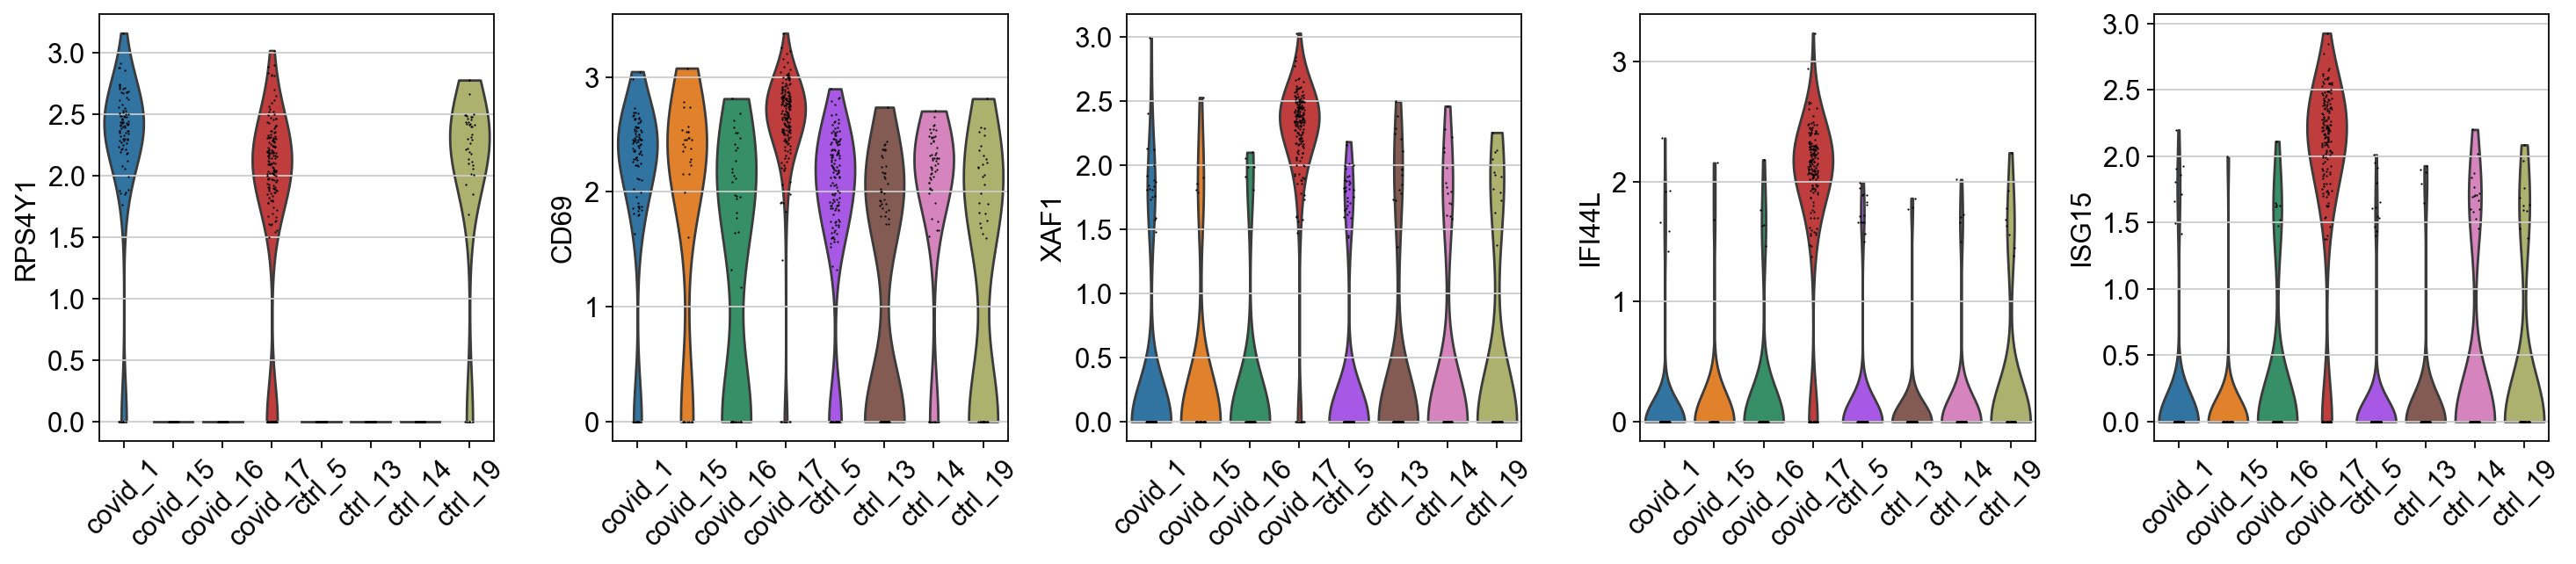

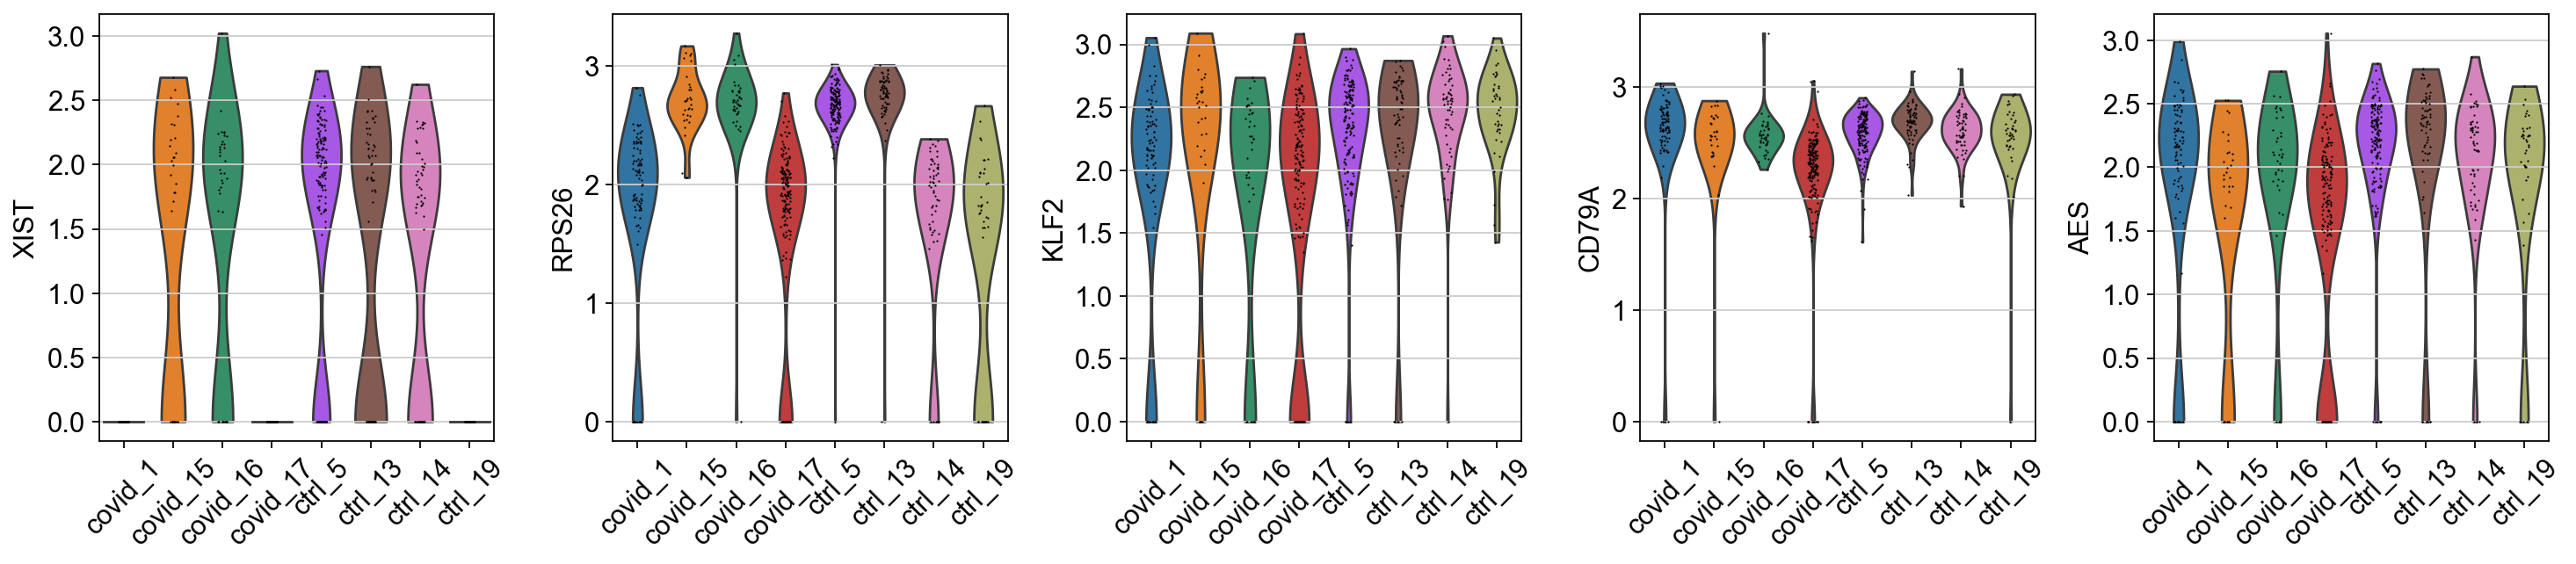

In [32]:
genes1 = sc.get.rank_genes_groups_df(cl1, group='Covid', key='wilcoxon')['names'][:5]
genes2 = sc.get.rank_genes_groups_df(cl1, group='Ctrl', key='wilcoxon')['names'][:5]
genes = genes1.tolist() +  genes2.tolist() 

sc.pl.violin(cl1, genes1, groupby='sample', rotation=45)
sc.pl.violin(cl1, genes2, groupby='sample', rotation=45)

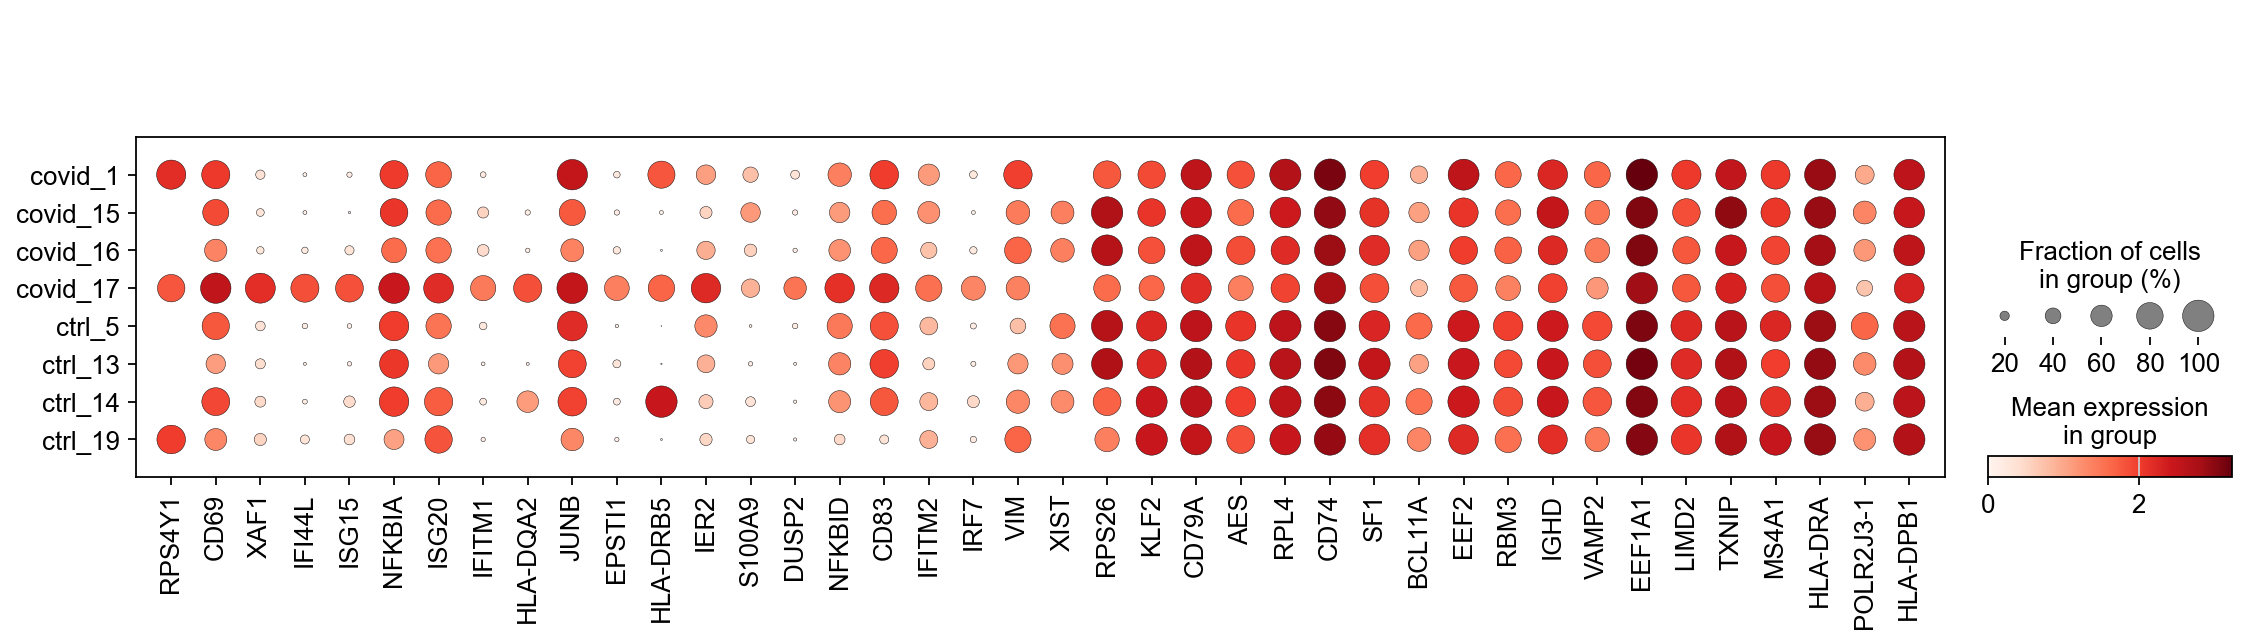

In [33]:
genes1 = sc.get.rank_genes_groups_df(cl1, group='Covid', key='wilcoxon')['names'][:20]
genes2 = sc.get.rank_genes_groups_df(cl1, group='Ctrl', key='wilcoxon')['names'][:20]
genes = genes1.tolist() +  genes2.tolist() 

sc.pl.dotplot(cl1,genes, groupby='sample')

In [34]:
cl1.obs['sample'].value_counts()

sample
covid_17    181
ctrl_5      153
covid_1      96
ctrl_13      68
ctrl_14      61
ctrl_19      42
covid_16     41
covid_15     32
Name: count, dtype: int64

## Balance Sample Groups
Subsample each sample to an equal number of cells (37 cells per sample). This ensures fair statistical comparison between groups and prevents sample size bias in downstream analysis.

In [35]:
target_cells = 37

tmp = [cl1[cl1.obs['sample'] == s] for s in cl1.obs['sample'].cat.categories]

for dat in tmp:
    if dat.n_obs > target_cells:
            sc.pp.subsample(dat, n_obs=target_cells)

cl1_sub = tmp[0].concatenate(*tmp[1:])

cl1_sub.obs['sample'].value_counts()

sample
covid_1     37
covid_16    37
covid_17    37
ctrl_5      37
ctrl_13     37
ctrl_14     37
ctrl_19     37
covid_15    32
Name: count, dtype: int64

ranking genes
    finished (0:00:00)


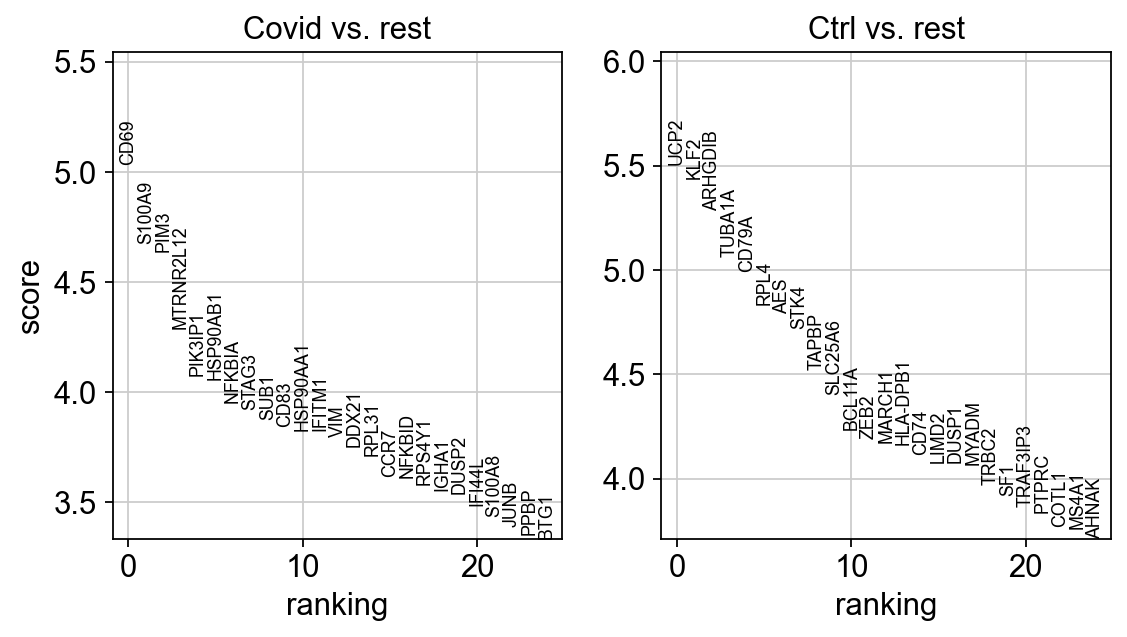

In [36]:
sc.tl.rank_genes_groups(cl1_sub, 'type', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(cl1_sub, n_genes=25, sharey=False, key="wilcoxon")

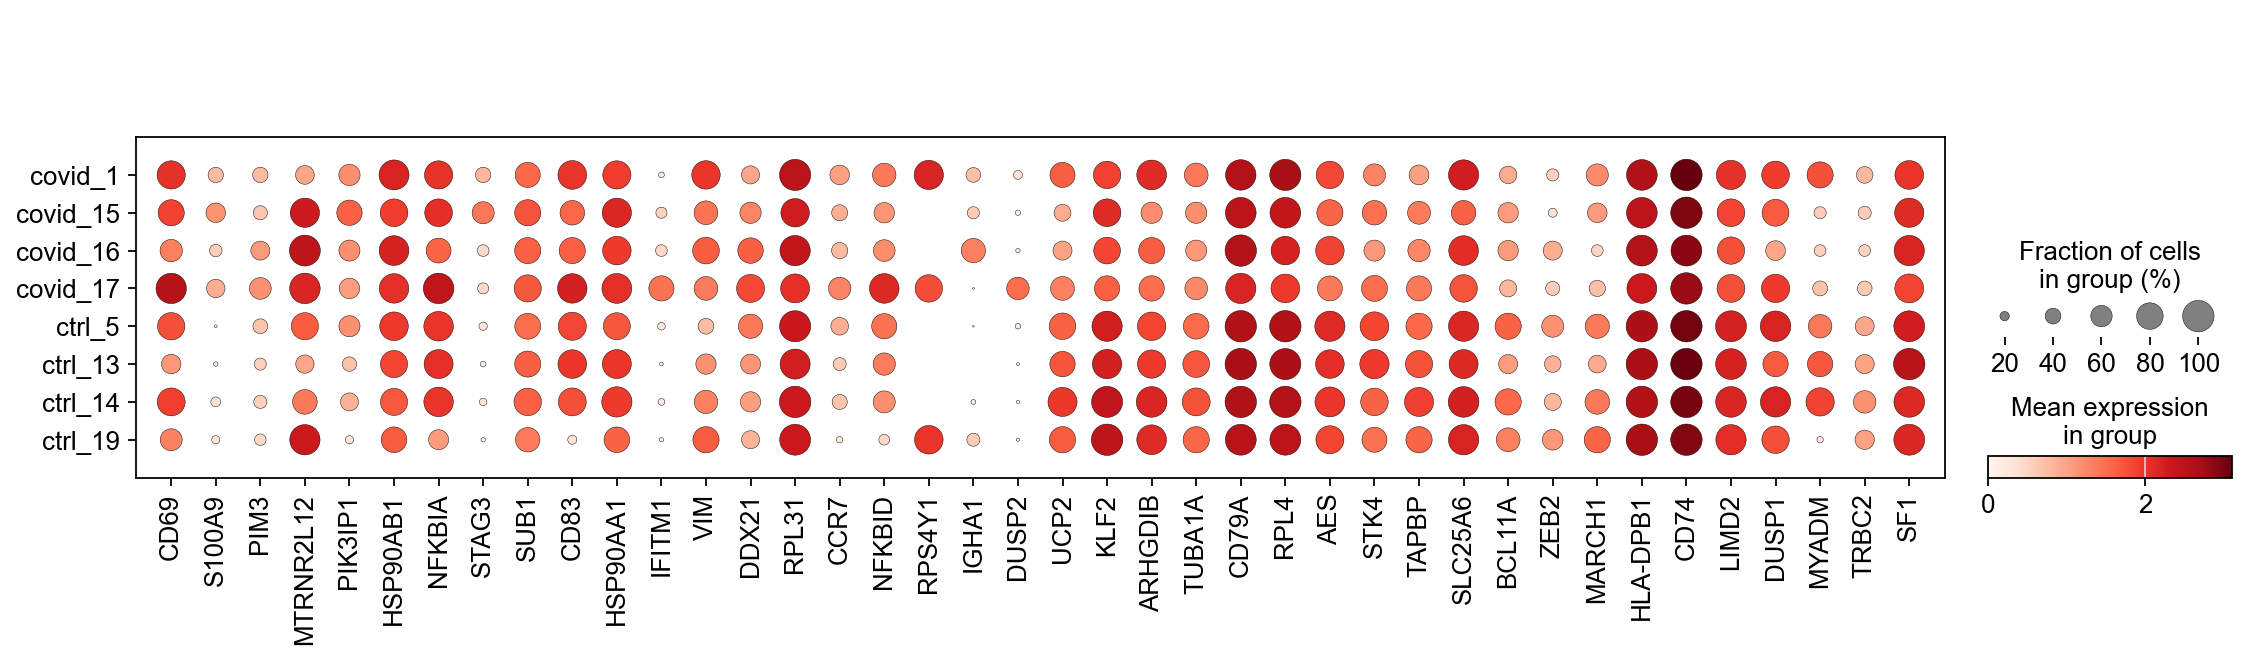

In [37]:
genes1 = sc.get.rank_genes_groups_df(cl1_sub, group='Covid', key='wilcoxon')['names'][:20]
genes2 = sc.get.rank_genes_groups_df(cl1_sub, group='Ctrl', key='wilcoxon')['names'][:20]
genes = genes1.tolist() +  genes2.tolist() 

sc.pl.dotplot(cl1,genes, groupby='sample')

In [38]:
#Available databases : ‘Human’, ‘Mouse’, ‘Yeast’, ‘Fly’, ‘Fish’, ‘Worm’ 
gene_set_names = gseapy.get_library_name(organism='Human')
print(gene_set_names)

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

## Functional Enrichment Analysis - GO Terms
Perform Gene Ontology (GO) enrichment on differentially expressed genes. This identifies biological processes, cellular components, and molecular functions associated with the transcriptional changes between COVID and control samples.

In [39]:
#?gseapy.enrichr
glist = sc.get.rank_genes_groups_df(cl1_sub, group='Covid', key='wilcoxon', log2fc_min=0.25, pval_cutoff=0.05)['names'].squeeze().str.strip().tolist()
print(len(glist))

6


In [41]:
enr_res = gseapy.enrichr(gene_list=glist, organism='Human', gene_sets='GO_Biological_Process_2021', cutoff=0.05)
enr_res.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,peptidyl-cysteine S-nitrosylation (GO:0018119),1/5,0.001499,0.026958,0,0,999.50,6499.559020,S100A9
1,GO_Biological_Process_2021,regulation of integrin biosynthetic process (G...,1/5,0.001499,0.026958,0,0,999.50,6499.559020,S100A9
2,GO_Biological_Process_2021,chronic inflammatory response (GO:0002544),1/5,0.001499,0.026958,0,0,999.50,6499.559020,S100A9
3,GO_Biological_Process_2021,positive regulation of tau-protein kinase acti...,1/6,0.001799,0.026958,0,0,799.56,5053.709148,HSP90AB1
4,GO_Biological_Process_2021,astrocyte development (GO:0014002),1/6,0.001799,0.026958,0,0,799.56,5053.709148,S100A9


<Axes: title={'center': 'GO_Biological_Process_2021'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

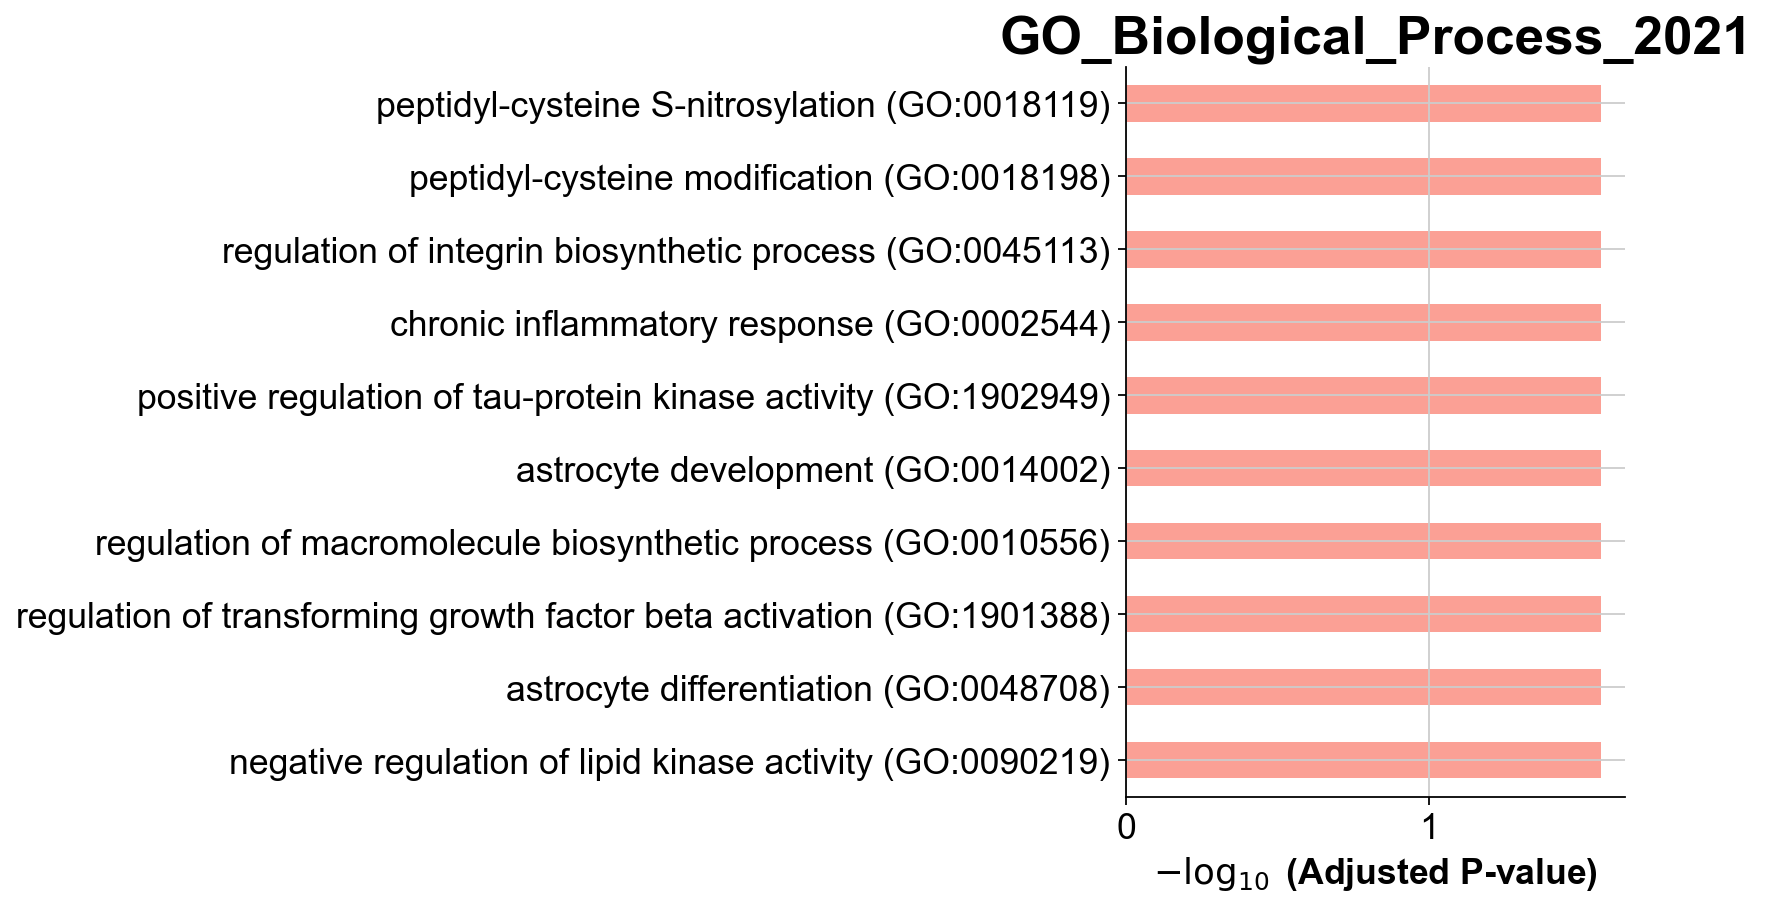

In [43]:
gseapy.barplot(enr_res.res2d,title='GO_Biological_Process_2021')

In [44]:
gene_rank = sc.get.rank_genes_groups_df(cl1_sub, group='Covid', key='wilcoxon')[['names','logfoldchanges']]
gene_rank.sort_values(by=['logfoldchanges'], inplace=True, ascending=False)

# calculate_qc_metrics will calculate number of cells per gene
sc.pp.calculate_qc_metrics(cl1, percent_top=None, log1p=False, inplace=True)

# filter for genes expressed in at least 30 cells.
gene_rank = gene_rank[gene_rank['names'].isin(cl1.var_names[cl1.var.n_cells_by_counts>30])]

gene_rank

,names,logfoldchanges
151,PF4,28.017332
210,MTRNR2L1,27.951775
316,CXCL8,27.453955
380,G0S2,27.165596
682,CCL3,26.821484
...,...,...
17544,CSTA,-25.910336
17546,MIAT,-25.982347
17538,TTC34,-26.053516
17901,CEP41,-26.089569


In [45]:
#Available databases : ‘Human’, ‘Mouse’, ‘Yeast’, ‘Fly’, ‘Fish’, ‘Worm’ 
gene_set_names = gseapy.get_library_name(organism='Human')
print(gene_set_names)

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

## Pathway Analysis - KEGG Pathways (GSEA PreRank)
Perform Gene Set Enrichment Analysis (GSEA) using ranked genes against KEGG pathway database. This identifies signaling pathways and biological systems affected by COVID-19 response, considering the full ranked gene list rather than just top genes.

In [46]:
res = gseapy.prerank(rnk=gene_rank, gene_sets='KEGG_2021_Human')

terms = res.res2d.Term
terms[:10]

2026-02-17 15:20:01,011 [WARNING] Duplicated values found in preranked stats: 13.88% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


0                    T cell receptor signaling pathway
1                       Sphingolipid signaling pathway
2                                  Cholinergic synapse
3                                  Cellular senescence
4             C-type lectin receptor signaling pathway
5                              IL-17 signaling pathway
6    PD-L1 expression and PD-1 checkpoint pathway i...
7                       Ubiquitin mediated proteolysis
8                                p53 signaling pathway
9                     Th1 and Th2 cell differentiation
Name: Term, dtype: object

[<Axes: xlabel='Gene Rank', ylabel='Ranked metric'>,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>]

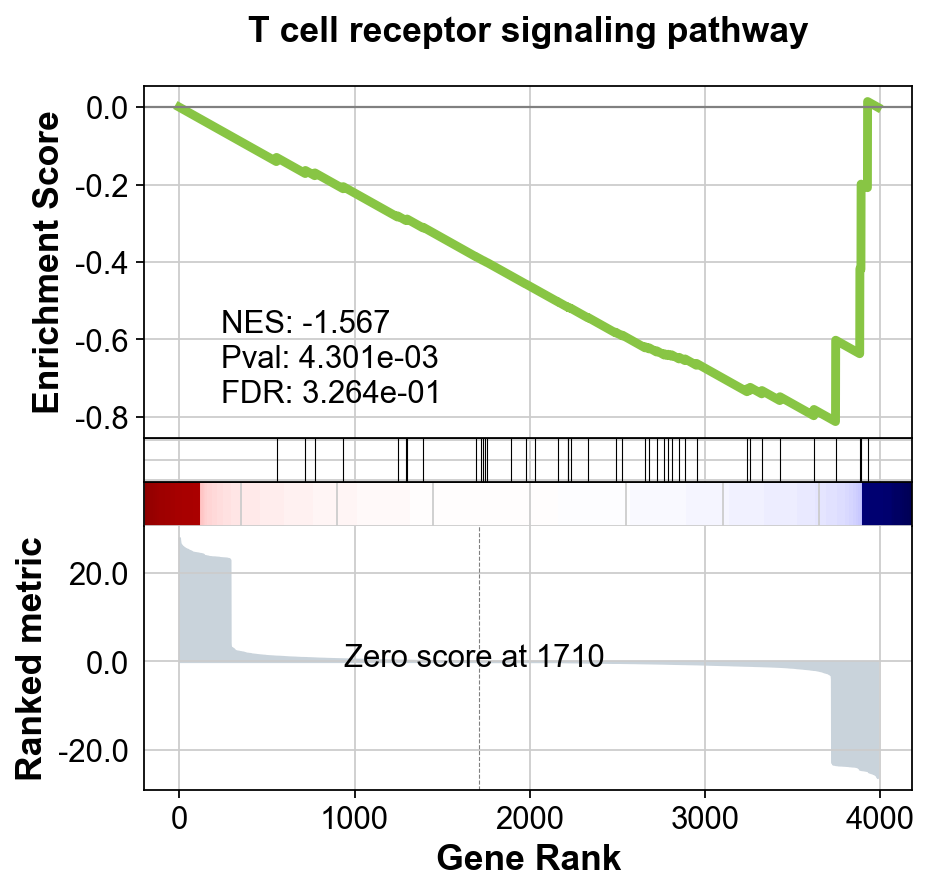

In [47]:
gseapy.gseaplot(rank_metric=res.ranking, term=terms[0], **res.results[terms[0]])